# Exp 5

# Required Libraries

In [23]:
import os, json, time, random
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Dict, Tuple, Optional
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix,
)
from tqdm import tqdm as _tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
try:
    import timm
except ImportError as e:
    raise SystemExit("timm is required. Install via pip install timm.")
from pandas.plotting import parallel_coordinates
import re
from PIL import Image, ImageOps

from scipy.ndimage import gaussian_filter1d

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import shutil

# Tuning deit-s parameters using 5-folds

In [ ]:

# Exp-5: DeiT-Small Hyperparameter Tuning via Random Search
# - Samples 30 random hyperparameter combinations (seed=42)
# - Evaluates each via 5-fold CV on 80% of data
# - Selects best by mean AUPRC
# - Saves: tuning_results.csv, hyperparameter_search_space.json, best_params.json, figures
# - Does NOT train final model (that's separate after tuning)




# Hyperparameter Search Space
SEARCH_SPACE = {
    'learning_rate': [0.00001, 0.001],      
    'weight_decay': [0.0, 0.1],            
    'warmup_epochs': [5, 10],             
    'batch_size': [32, 64],                 
}

NUM_COMBINATIONS = 30
RANDOM_SEED_TUNING = 42

# Training defaults
DEFAULT_EPOCHS = 50
DEFAULT_IMG_SIZE = 224
DEFAULT_NUM_WORKERS = 0
DEFAULT_OPTIM = "adamw"
DEFAULT_DROP_PATH_RATE = 0.1
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# Utils (from Exp-3)
def _merge_logits_for_loss_and_pred(logits):
    if isinstance(logits, tuple):
        cls, dist = logits
        merged = 0.5 * (cls + dist)
        return merged, merged
    return logits, logits

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

def device_str():
    return "cuda" if torch.cuda.is_available() else "cpu"

@dataclass
class HyperParams:
    learning_rate: float
    weight_decay: float
    warmup_epochs: int
    batch_size: int
    epochs: int = DEFAULT_EPOCHS
    img_size: int = DEFAULT_IMG_SIZE
    num_workers: int = DEFAULT_NUM_WORKERS
    drop_path_rate: float = DEFAULT_DROP_PATH_RATE

# Data
def build_transforms(img_size: int):
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([transforms.ColorJitter(0.1, 0.1, 0.1, 0.02)], p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return train_tf, eval_tf

def build_dataloaders_fold(fold_path: Path, img_size: int, batch_size: int, num_workers: int):
    train_dir, val_dir = fold_path / "train", fold_path / "val"
    if not train_dir.exists() or not val_dir.exists():
        raise FileNotFoundError(f"Missing train/ or val/ under {fold_path}")
    
    train_tf, eval_tf = build_transforms(img_size)
    train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
    val_ds = datasets.ImageFolder(val_dir, transform=eval_tf)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, 
                             num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, 
                           num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, train_ds.classes

 
# Model
def build_deit_small(num_classes: int, drop_path_rate: float = 0.1):
    model = timm.create_model(
        "deit_small_patch16_224",
        pretrained=True,
        num_classes=num_classes,
        drop_path_rate=drop_path_rate,
    )
    return model

def make_optimizer(model: nn.Module, hp: HyperParams):
    params = [p for p in model.parameters() if p.requires_grad]
    scaled_lr = hp.learning_rate * (hp.batch_size / 256.0)
    return optim.AdamW(params, lr=scaled_lr, weight_decay=hp.weight_decay)

def make_warmup_cosine_scheduler(optimizer, hp: HyperParams, steps_per_epoch: int):
    total_steps = hp.epochs * steps_per_epoch
    warmup_steps = hp.warmup_epochs * steps_per_epoch
    
    def lr_lambda(step):
        if step < warmup_steps and warmup_steps > 0:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


# Train / Eval
def train_one_epoch(model, loader, device, criterion, optimizer):
    model.train()
    losses, correct, total = [], 0, 0
    
    with _tqdm(loader, desc="Train", leave=False) as pbar:
        for images, targets in pbar:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss_logits, _ = _merge_logits_for_loss_and_pred(logits)
            loss = criterion(loss_logits, targets)
            loss.backward()
            optimizer.step()
            
            losses.append(loss.item())
            with torch.no_grad():
                preds = loss_logits.argmax(dim=1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)
            
            pbar.set_postfix({'loss': float(np.mean(losses)) if losses else 0})
    
    return float(np.mean(losses)), correct / max(1, total)

@torch.no_grad()
def evaluate(model, loader, device, criterion, class_names: List[str]):
    model.eval()
    losses, all_targets, all_probs, all_preds = [], [], [], []
    
    with _tqdm(loader, desc="Validate", leave=False) as pbar:
        for images, targets in pbar:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            
            logits = model(images)
            loss_logits, pred_logits = _merge_logits_for_loss_and_pred(logits)
            loss = criterion(loss_logits, targets)
            losses.append(loss.item())
            
            probs = torch.softmax(pred_logits, dim=1)
            preds = probs.argmax(dim=1)
            all_targets.append(targets.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            
            pbar.set_postfix({'loss': np.mean(losses)})
    
    y_true = np.concatenate(all_targets)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)
    
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    metrics = {
        "loss": float(np.mean(losses)),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "tp": 0,
        "tn": 0,
        "fp": 0,
        "fn": 0,
    }
    
    if len(class_names) == 2:
        try:
            pos_idx = class_names.index("defective")
        except:
            pos_idx = 1
        
        y_true_bin = (y_true == pos_idx).astype(int)
        y_pred_bin = (y_pred == pos_idx).astype(int)
        
        tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
        metrics.update({
            "tp": int(tp),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
        })
        
        try:
            auroc = roc_auc_score(y_true_bin, y_prob[:, pos_idx])
        except:
            auroc = np.nan
        
        try:
            auprc = average_precision_score(y_true_bin, y_prob[:, pos_idx])
        except:
            auprc = np.nan
        
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_bin, y_pred_bin, average="binary", zero_division=0
        )
        
        metrics.update({
            "auroc": float(auroc),
            "auprc": float(auprc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
        })
    
    return metrics


# Random Search
def sample_random_hyperparams(num_combinations: int, seed: int = 42) -> List[HyperParams]:
    """Sample 30 random hyperparameter combinations."""
    rng = np.random.RandomState(seed)
    combinations = []
    
    for i in range(num_combinations):
        # Sample each parameter
        lr = 10 ** rng.uniform(np.log10(SEARCH_SPACE['learning_rate'][0]), 
                               np.log10(SEARCH_SPACE['learning_rate'][1]))
        wd = rng.uniform(SEARCH_SPACE['weight_decay'][0], SEARCH_SPACE['weight_decay'][1])
        warmup = int(rng.randint(SEARCH_SPACE['warmup_epochs'][0], 
                             SEARCH_SPACE['warmup_epochs'][1] + 1))
        bs = int(rng.choice([32, 64]))  # discrete choice
        
        combinations.append(HyperParams(
            learning_rate=float(lr),
            weight_decay=float(wd),
            warmup_epochs=warmup,
            batch_size=bs
        ))
    
    return combinations

def get_predictions_with_filenames(model, loader, device, class_names: List[str], 
                                    fold_path: Path, split: str):
    """Get predictions with filenames for train/val sets."""
    model.eval()
    all_filenames, all_targets, all_preds, all_probs = [], [], [], []
    
    # Get the actual image folder path (split is "train" or "val")
    split_dir = fold_path / split
    
    # Create dataset to get filenames
    dataset = datasets.ImageFolder(split_dir)
    
    with torch.no_grad():
        batch_idx = 0
        for images, targets in loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            
            logits = model(images)
            loss_logits, pred_logits = _merge_logits_for_loss_and_pred(logits)
            probs = torch.softmax(pred_logits, dim=1)
            preds = probs.argmax(dim=1)
            
            # Get filenames for this batch
            batch_size = images.size(0)
            for i in range(batch_size):
                img_idx = batch_idx * loader.batch_size + i
                if img_idx < len(dataset.imgs):
                    filename = os.path.basename(dataset.imgs[img_idx][0])
                    all_filenames.append(filename)
                    all_targets.append(targets[i].cpu().item())
                    all_preds.append(preds[i].cpu().item())
                    all_probs.append(probs[i].cpu().numpy())
            batch_idx += 1
    
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    
    return all_filenames, y_true, y_pred, y_prob

def evaluate_hyperparams(hp: HyperParams, fold_paths: List[Path], device: str, 
                        out_dir: Path, combo_idx: int) -> Dict:
    """
    Evaluate a single hyperparameter combination using 5-fold CV.
    Returns dict with mean/std metrics across 5 folds.
    Saves epoch-by-epoch logs for each fold.
    Saves train/val predictions with filenames for each fold.
    """
    cv_results = []
    all_epoch_logs = []

    
    for fold_idx, fold_path in enumerate(fold_paths):
        fold_name = fold_path.name
        print(f"  Fold {fold_idx + 1}/{len(fold_paths)}: {fold_path.name}")
        set_seed(RANDOM_SEED_TUNING) 
        
        # Load data
        train_loader, val_loader, class_names = build_dataloaders_fold(
            fold_path, hp.img_size, hp.batch_size, hp.num_workers
        )
        num_classes = len(class_names)
        
        # Build model
        model = build_deit_small(num_classes, hp.drop_path_rate).to(device)
        
        # Loss with class weights
        train_targets = []
        for _, targets in train_loader:
            train_targets.extend(targets.numpy().tolist())
        class_counts = np.bincount(train_targets, minlength=num_classes)
        class_weights = class_counts.max() / np.clip(class_counts, 1, None)
        criterion = nn.CrossEntropyLoss(
            weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
        )
        
        # Optimizer & scheduler
        optimizer = make_optimizer(model, hp)
        scheduler = make_warmup_cosine_scheduler(optimizer, hp, steps_per_epoch=len(train_loader))
        
        # Prepare epoch log storage
        epoch_logs_fold = []
        
        # Train
        best_auprc = -np.inf
        for epoch in range(hp.epochs):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, device, criterion, optimizer)
            scheduler.step()
            
            val_metrics = evaluate(model, val_loader, device, criterion, class_names)
            
            # Compute metrics for logging
            epoch_log = {
                'combo_idx': combo_idx,
                'fold': fold_idx,
                'epoch': epoch,
                'train_loss': tr_loss,
                'train_acc': tr_acc,
                'val_loss': val_metrics['loss'],
                'val_accuracy': val_metrics['accuracy'],
                'val_balanced_accuracy': val_metrics['balanced_accuracy'],
                'val_auprc': val_metrics.get('auprc', np.nan),
                'val_auroc': val_metrics.get('auroc', np.nan),
                'val_precision': val_metrics.get('precision', np.nan),
                'val_recall': val_metrics.get('recall', np.nan),
                'val_f1': val_metrics.get('f1', np.nan),
                'val_tp': int(val_metrics.get('tp', 0)),
                'val_tn': int(val_metrics.get('tn', 0)),
                'val_fp': int(val_metrics.get('fp', 0)),
                'val_fn': int(val_metrics.get('fn', 0)),
                'lr': optimizer.param_groups[0]['lr'],
            }
            epoch_logs_fold.append(epoch_log)
            all_epoch_logs.append(epoch_log)
            
            # Track best by AUPRC
            if val_metrics.get('auprc', -np.inf) > best_auprc:
                best_auprc = val_metrics['auprc']
            
            # Print progress every 10 epochs
            if (epoch + 1) % 10 == 0 or epoch == 0:
                _tqdm.write(f"      Epoch {epoch + 1}/{hp.epochs}: Val AUPRC={val_metrics.get('auprc', np.nan):.4f}, F1={val_metrics.get('f1', np.nan):.4f}, Loss={val_metrics['loss']:.4f}")
        
        print(f"    ✓ Best AUPRC: {best_auprc:.4f} | Final Val Loss: {val_metrics['loss']:.4f} | F1: {val_metrics.get('f1', np.nan):.4f}")
        
        # Save epoch logs for this fold
        fold_csv_path = out_dir / f"combo{combo_idx:02d}_fold{fold_idx}_epochs.csv"
        fold_df = pd.DataFrame(epoch_logs_fold)
        fold_df.to_csv(fold_csv_path, index=False)
        
        # Save train predictions with filenames
        train_filenames, train_y_true, train_y_pred, train_y_prob = get_predictions_with_filenames(
            model, train_loader, device, class_names, fold_path, "train"
        )
        train_preds_df = pd.DataFrame({
            'filename': train_filenames,
            'y_true': train_y_true,
            'y_pred': train_y_pred,
            'p_class_0': train_y_prob[:, 0],
            'p_class_1': train_y_prob[:, 1],
        })
        train_preds_path = out_dir / f"combo{combo_idx:02d}_fold{fold_idx}_train_predictions.csv"
        train_preds_df.to_csv(train_preds_path, index=False)
        
        # Save val predictions with filenames
        val_filenames, val_y_true, val_y_pred, val_y_prob = get_predictions_with_filenames(
            model, val_loader, device, class_names, fold_path, "val"
        )
        val_preds_df = pd.DataFrame({
            'filename': val_filenames,
            'y_true': val_y_true,
            'y_pred': val_y_pred,
            'p_class_0': val_y_prob[:, 0],
            'p_class_1': val_y_prob[:, 1],
        })
        val_preds_path = out_dir / f"combo{combo_idx:02d}_fold{fold_idx}_val_predictions.csv"
        val_preds_df.to_csv(val_preds_path, index=False)
        
        cv_results.append({
            'fold': fold_idx,
            'best_auprc': best_auprc,
            'final_val_loss': val_metrics['loss'],
            'final_val_f1': val_metrics.get('f1', np.nan),
            'final_val_acc': val_metrics['accuracy'],
        })
    
    # Save all epoch logs for this combo
    combo_csv_path = out_dir / f"combo{combo_idx:02d}_all_epochs.csv"
    combo_df = pd.DataFrame(all_epoch_logs)
    combo_df.to_csv(combo_csv_path, index=False)
    
    # Aggregate across folds
    auprcs = [r['best_auprc'] for r in cv_results]
    result = {
        'combo_idx': combo_idx,
        'learning_rate': hp.learning_rate,
        'weight_decay': hp.weight_decay,
        'warmup_epochs': hp.warmup_epochs,
        'batch_size': hp.batch_size,
        'mean_auprc': float(np.mean(auprcs)),
        'std_auprc': float(np.std(auprcs)),
        'fold_details': cv_results,
    }
    
    return result

# Main Tuning
def run_hyperparameter_tuning(cvset_root: str, out_dir: str, device: Optional[str] = None):
    """Main tuning loop: sample 30 combos, evaluate via 5-fold CV."""
    device = device or device_str()
    print(f"Using device: {device}")
    
    cvset_root = Path(cvset_root)
    out_root = Path(out_dir)
    out_root.mkdir(parents=True, exist_ok=True)
    
    # Discover folds
    folds_dir = cvset_root / "folds"
    fold_paths = sorted([d for d in folds_dir.iterdir() if d.is_dir() and d.name.startswith("fold_")])
    if not fold_paths:
        raise FileNotFoundError(f"No folds found in {folds_dir}")
    print(f"Found {len(fold_paths)} folds: {[f.name for f in fold_paths]}")
    
    # Sample random hyperparameters
    print(f"\nSampling {NUM_COMBINATIONS} random hyperparameter combinations (seed={RANDOM_SEED_TUNING})...")
    hp_combinations = sample_random_hyperparams(NUM_COMBINATIONS, seed=RANDOM_SEED_TUNING)
    
    # Save search space
    sampled_combos = []
    for hp in hp_combinations:
        sampled_combos.append({
            'learning_rate': float(hp.learning_rate),
            'weight_decay': float(hp.weight_decay),
            'warmup_epochs': int(hp.warmup_epochs),
            'batch_size': int(hp.batch_size),
        })
    
    search_space_log = {
        'num_combinations': NUM_COMBINATIONS,
        'random_seed': RANDOM_SEED_TUNING,
        'search_space': {k: [float(v) for v in SEARCH_SPACE[k]] for k in SEARCH_SPACE},
        'sampled_combinations': sampled_combos
    }
    with open(out_root / "hyperparameter_search_space.json", "w") as f:
        json.dump(search_space_log, f, indent=2)
    
    # Evaluate each combination
    print("\nEvaluating hyperparameter combinations via 5-fold CV...")
    all_results = []
    
    for combo_idx, hp in enumerate(hp_combinations):
        print(f"\n[{combo_idx + 1}/{NUM_COMBINATIONS}] Evaluating: lr={hp.learning_rate:.6f}, "
              f"wd={hp.weight_decay:.6f}, warmup={hp.warmup_epochs}, bs={hp.batch_size}")
        
        result = evaluate_hyperparams(hp, fold_paths, device, out_root, combo_idx)
        all_results.append(result)
        
        print(f"  → Mean AUPRC: {result['mean_auprc']:.4f} ± {result['std_auprc']:.4f}")
    
    # Save detailed results to CSV
    results_df = pd.DataFrame([
        {
            'combo_idx': r['combo_idx'],
            'learning_rate': r['learning_rate'],
            'weight_decay': r['weight_decay'],
            'warmup_epochs': r['warmup_epochs'],
            'batch_size': r['batch_size'],
            'mean_auprc': r['mean_auprc'],
            'std_auprc': r['std_auprc'],
        }
        for r in all_results
    ])
    results_df.to_csv(out_root / "tuning_results.csv", index=False)
    print(f"\nSaved tuning results to: {out_root / 'tuning_results.csv'}")



## run function

In [ ]:

cudnn.benchmark = False
cudnn.deterministic = True
torch.set_num_threads(4)

# Entry Point
if __name__ == "__main__":
    CVSET_ROOT = "./blurclahe_data_folds/blurclahe_inner_seed79"
    OUT_DIR = "results_experiment5_tuning"
    
    best_result = run_hyperparameter_tuning(
        cvset_root=CVSET_ROOT,
        out_dir=OUT_DIR,
        device="cuda"
    )
    
    print(f"\nAll results saved to: {OUT_DIR}/")
    print(f"  - tuning_results.csv: Detailed results for all 30 combinations")
    print(f"  - best_params.json: Best hyperparameters found")
    print(f"  - hyperparameter_search_space.json: Search space configuration")
    print(f"  - Figures: fig_tuning_*.png for publication")

Using device: cuda
Found 5 folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']

Sampling 30 random hyperparameter combinations (seed=42)...

Evaluating hyperparameter combinations via 5-fold CV...

[1/30] Evaluating: lr=0.000056, wd=0.095071, warmup=7, bs=64
  Fold 1/5: fold_0


      Epoch 1/50: Val AUPRC=0.7025, F1=0.3167, Loss=0.5986


      Epoch 10/50: Val AUPRC=0.9991, F1=0.9802, Loss=0.2924


      Epoch 20/50: Val AUPRC=0.9899, F1=0.9436, Loss=0.1300


      Epoch 30/50: Val AUPRC=0.9550, F1=0.9005, Loss=0.2020


...

      Epoch 10/50: Val AUPRC=0.6052, F1=0.6170, Loss=0.3609


      Epoch 20/50: Val AUPRC=0.7144, F1=0.6593, Loss=0.2772


      Epoch 30/50: Val AUPRC=0.7132, F1=0.6667, Loss=0.3899


      Epoch 40/50: Val AUPRC=0.7593, F1=0.6923, Loss=0.2940


      Epoch 50/50: Val AUPRC=0.7491, F1=0.6286, Loss=0.3174
    ✓ Best AUPRC: 0.8022 | Final Val Loss: 0.3174 | F1: 0.6286
  → Mean AUPRC: 0.9147 ± 0.0954

Saved tuning results to: results_experiment5_correct\tuning_results.csv

BEST HYPERPARAMETER COMBINATION (by Mean AUPRC)
Combination #14 / 30
  Learning Rate:  0.000464
  Weight Decay:   0.017336
  Warmup Epochs:  5
  Batch Size:     64
  Mean AUPRC:     0.9470
  Std AUPRC:      0.0586

Saved: results_experiment5_correct\fig_tuning_search_progression.png
Saved: results_experiment5_correct\fig_tuning_heatmap_lr_wd.png
Saved: results_experiment5_correct\fig_top5_combinations.png

All results saved to: results_experiment5_correct/
  - tuning_results.csv: Detailed results for all 30 combinations
  - best_params.json: Best hyperparameters found
  - hyperparameter_search_space.json: Search space configuration
  - Figures: fig_tuning_*.png for publication


## add columns to the files savedwith additional metrics

In [2]:

# Aggregate mean/std metrics (AUPRC, F1, precision, recall, TP, TN, FP, FN)
# from all per-fold CSV logs into a new tuning_results_additional_columns.csv.

# It recomputes AUPRC and other metrics directly from per-fold results,
# ignoring those in the original tuning_results.csv.

# CONFIG 
OUT_DIR = Path("results_experiment5_tuning")  
TUNING_RESULTS_CSV = OUT_DIR / "tuning_results.csv"
OUTPUT_CSV = OUT_DIR / "tuning_results_additional_columns.csv"

# LOAD ORIGINAL FILE
if not TUNING_RESULTS_CSV.exists():
    raise FileNotFoundError(f"Cannot find {TUNING_RESULTS_CSV}")

tuning_df = pd.read_csv(TUNING_RESULTS_CSV)
fold_files = list(OUT_DIR.glob("combo*_fold*_epochs.csv"))
if not fold_files:
    raise FileNotFoundError(f"No combo*_fold*_epochs.csv files found in {OUT_DIR}")

print(f"Found {len(fold_files)} per-fold logs.")

# RECOMPUTE METRICS 
agg_rows = []

for combo_idx in sorted(tuning_df["combo_idx"].unique()):
    combo_pattern = f"combo{combo_idx:02d}_fold"
    combo_files = [f for f in fold_files if combo_pattern in f.name]
    if not combo_files:
        print(f"⚠️ No folds found for combo {combo_idx}")
        continue

    fold_records = []
    for file in combo_files:
        df = pd.read_csv(file)
        # Pick the epoch with best AUPRC (not final)
        if "val_auprc" in df.columns:
            best_idx = df["val_auprc"].idxmax()
        else:
            best_idx = df.index[-1]

        best = df.loc[best_idx]
        fold_records.append({
            "auprc": best.get("val_auprc", np.nan),
            "f1": best.get("val_f1", np.nan),
            "precision": best.get("val_precision", np.nan),
            "recall": best.get("val_recall", np.nan),
            "tp": best.get("val_tp", np.nan),
            "tn": best.get("val_tn", np.nan),
            "fp": best.get("val_fp", np.nan),
            "fn": best.get("val_fn", np.nan),
        })

    fold_df = pd.DataFrame(fold_records)
    agg_rows.append({
        "combo_idx": combo_idx,
        "mean_auprc": fold_df["auprc"].mean(),
        "std_auprc": fold_df["auprc"].std(),
        "mean_f1": fold_df["f1"].mean(),
        "std_f1": fold_df["f1"].std(),
        "mean_precision": fold_df["precision"].mean(),
        "std_precision": fold_df["precision"].std(),
        "mean_recall": fold_df["recall"].mean(),
        "std_recall": fold_df["recall"].std(),
        "mean_fp": fold_df["fp"].mean(),
        "mean_tp": fold_df["tp"].mean(),
        "mean_fn": fold_df["fn"].mean(),
        "mean_tn": fold_df["tn"].mean(),
    })

agg_df = pd.DataFrame(agg_rows)

# MERGE WITH OTHER HYPERPARAMETERS 
merged = tuning_df.drop(columns=["mean_auprc", "std_auprc"], errors="ignore")
merged = merged.merge(agg_df, on="combo_idx", how="left")

# SAVE 
merged.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved recomputed metrics to: {OUTPUT_CSV}")
print("Recomputed columns:",
      ", ".join([c for c in agg_df.columns if c != "combo_idx"]))


Found 150 per-fold logs.

Saved recomputed metrics to: results_experiment5_tuning\tuning_results_additional_columns.csv
Recomputed columns: mean_auprc, std_auprc, mean_f1, std_f1, mean_precision, std_precision, mean_recall, std_recall, mean_fp, mean_tp, mean_fn, mean_tn


## Find best combination of parameters

In [4]:

# Extract per-fold metrics (f1, precision, recall, auprc, fp, fn, tp, tn)
# for the BEST combo (highest mean AUPRC),
# and compute their average across folds.

# CONFIG
OUT_DIR = Path("results_experiment5_tuning") 
TUNING_RESULTS = OUT_DIR / "tuning_results.csv"  # tuning_results_recomputed or tuning_results.csv if not recomputed
OUTPUT_CSV = OUT_DIR / "best_combo_fold_metrics.csv"

#LOAD BEST COMBO 
tuning_df = pd.read_csv(TUNING_RESULTS)
best_combo_idx = tuning_df.loc[tuning_df["mean_auprc"].idxmax(), "combo_idx"]
print(f"Best combo_idx: {best_combo_idx}")

#LOAD ALL FOLDS FOR BEST COMBO 
fold_files = sorted(OUT_DIR.glob(f"combo{int(best_combo_idx):02d}_fold*_epochs.csv"))
if not fold_files:
    raise FileNotFoundError(f"No folds found for combo {best_combo_idx}")

fold_rows = []
for file in fold_files:
    df = pd.read_csv(file)
    # select the epoch with best AUPRC
    best_idx = df["val_auprc"].idxmax()
    best = df.loc[best_idx]
    fold_name = file.stem.split("_fold")[1].split("_")[0]
    
    fold_rows.append({
        "fold": fold_name,
        "f1": best.get("val_f1", np.nan),
        "precision": best.get("val_precision", np.nan),
        "recall": best.get("val_recall", np.nan),
        "auprc": best.get("val_auprc", np.nan),
        "fp": best.get("val_fp", np.nan),
        "fn": best.get("val_fn", np.nan),
        "tp": best.get("val_tp", np.nan),
        "tn": best.get("val_tn", np.nan),
    })

# ADD AVERAGE ROW 
fold_df = pd.DataFrame(fold_rows)
avg_row = fold_df.mean(numeric_only=True)
avg_row["fold"] = "mean"
fold_df = pd.concat([fold_df, pd.DataFrame([avg_row])], ignore_index=True)

# SAVE 
fold_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n Saved best combo fold metrics to: {OUTPUT_CSV}")
print(fold_df)


Best combo_idx: 13

 Saved best combo fold metrics to: results_experiment5_tuning\best_combo_fold_metrics.csv
   fold        f1  precision    recall     auprc    fp    fn    tp     tn
0     0  0.980198   0.970588  0.990000  0.999312   3.0   1.0  99.0  187.0
1     1  0.968421   0.938776  1.000000  0.998388   6.0   0.0  92.0  112.0
2     2  0.767123   0.903226  0.666667  0.866011   3.0  14.0  28.0  175.0
3     3  0.784000   0.644737  1.000000  0.985443  27.0   0.0  49.0  214.0
4     4  0.542373   0.941176  0.380952  0.885749   1.0  26.0  16.0  247.0
5  mean  0.808423   0.879701  0.807524  0.946981   8.0   8.2  56.8  187.0


## Check top five auprc to compare other metrics

In [5]:

# CONFIG 
OUT_DIR = Path("results_experiment5_tuning")              
INPUT_CSV = OUT_DIR / "tuning_results_additional_columns.csv"
OUTPUT_TOP5_CSV = OUT_DIR / "top5_hyperparam_combinations.csv"

# LOAD DATA 
df = pd.read_csv(INPUT_CSV)
# Ensure columns are as expected
print("Columns in dataframe:", list(df.columns))

# SELECT TOP 5 BY mean_auprc
top5 = df.sort_values(by="mean_auprc", ascending=False).head(5)

# SAVE TOP 5 TO CSV
top5.to_csv(OUTPUT_TOP5_CSV, index=False)
print(f"Saved top 5 combinations to {OUTPUT_TOP5_CSV}")
print(top5)


Columns in dataframe: ['combo_idx', 'learning_rate', 'weight_decay', 'warmup_epochs', 'batch_size', 'mean_auprc', 'std_auprc', 'mean_f1', 'std_f1', 'mean_precision', 'std_precision', 'mean_recall', 'std_recall', 'mean_fp', 'mean_tp', 'mean_fn', 'mean_tn']
Saved top 5 combinations to results_experiment5_tuning\top5_hyperparam_combinations.csv
    combo_idx  learning_rate  weight_decay  warmup_epochs  batch_size  \
13         13       0.000464      0.017336              5          64   
11         11       0.000414      0.030461              9          64   
16         16       0.000484      0.044975              6          64   
25         25       0.000532      0.062330              6          32   
3           3       0.000261      0.002058              6          64   

    mean_auprc  std_auprc   mean_f1    std_f1  mean_precision  std_precision  \
13    0.946981   0.065510  0.808423  0.179019        0.879701       0.133502   
11    0.942611   0.073639  0.803905  0.127683        0.84

In [6]:
# === Save “Top 5 hyperparameter combinations” table with rank & ± format ===
# Select top-5
top5 = df.nlargest(5, "mean_auprc").copy().reset_index(drop=True)

# Add Rank 1-5
top5.insert(0, "Rank", np.arange(1, len(top5)+1))

# Prepare the columns we want
metrics = ["auprc", "precision", "recall", "f1"]
table_rows = []
for _, row in top5.iterrows():
    entry = {
        "Rank": row["Rank"],
        "learning_rate": row["learning_rate"],
        "weight_decay": row["weight_decay"],
        "warmup_epochs": int(row["warmup_epochs"]),
        "batch_size": int(row["batch_size"]),
    }
    # For each metric: combine mean ± std if std exists
    for m in metrics:
        mean_col = f"mean_{m}"
        std_col  = f"std_{m}"
        if mean_col in row.index:
            mean_val = row[mean_col]
            std_val  = row.get(std_col, np.nan)
            if not np.isnan(std_val):
                entry[f"{m.upper()}"] = f"{mean_val:.4f} ± {std_val:.4f}"
            else:
                entry[f"{m.upper()}"] = f"{mean_val:.4f}"
    table_rows.append(entry)

top5_table = pd.DataFrame(table_rows)

# Save to CSV
top5_table.to_csv(OUT_DIR / "top5_hyperparam_combinations_table.csv", index=False)
print("Saved top5 table to: top5_hyperparam_combinations_table.csv")

# (Optional) Save to LaTeX
try:
    latex_str = top5_table.to_latex(index=False,
                                    float_format="%.4f",
                                    caption="Top 5 hyperparameter combinations ranked by mean AUPRC (5-fold CV).",
                                    label="tab:top5_hyperparams")
    with open(OUT_DIR / "top5_hyperparam_combinations_table.tex", "w") as f:
        f.write(latex_str)
    print("Saved LaTeX version: top5_hyperparam_combinations_table.tex")
except Exception as e:
    print("Could not save LaTeX version:", e)


Saved top5 table to: top5_hyperparam_combinations_table.csv
Saved LaTeX version: top5_hyperparam_combinations_table.tex


## Save file with chosen best parameters

In [7]:
# CONFIG 
OUT_DIR = Path("results_experiment5_tuning")  
CSV_PATH = OUT_DIR / "tuning_results_additional_columns.csv"  # or tuning_results.csv
OUTPUT_JSON = OUT_DIR / "best_params.json"

#LOAD RESULTS
df = pd.read_csv(CSV_PATH)

# FIND BEST COMBINATION 
best_row = df.loc[df["mean_auprc"].idxmax()]
best_params = best_row.to_dict()

# SAVE TO JSON 
with open(OUTPUT_JSON, "w") as f:
    json.dump(best_params, f, indent=2)

print(f"Best hyperparameters saved to: {OUTPUT_JSON}")
print(best_params)


Best hyperparameters saved to: results_experiment5_tuning\best_params.json
{'combo_idx': 13.0, 'learning_rate': 0.0004638630972397, 'weight_decay': 0.0173364653507772, 'warmup_epochs': 5.0, 'batch_size': 64.0, 'mean_auprc': 0.9469806287675024, 'std_auprc': 0.0655095524278701, 'mean_f1': 0.8084230482921448, 'std_f1': 0.1790187483699807, 'mean_precision': 0.8797005729286621, 'std_precision': 0.1335019595288418, 'mean_recall': 0.8075238095238095, 'std_recall': 0.278026818067297, 'mean_fp': 8.0, 'mean_tp': 56.8, 'mean_fn': 8.2, 'mean_tn': 187.0}


## generate plots

In [11]:

# Generate summary plots for Exp-5 hyperparameter tuning results.

# Input:
#   results_experiment5_correct/tuning_results_additional_columns.csv
# Output:
#   - hist_auprc_distribution.png
#   - boxplot_batchsize_auprc.png
#   - learning_curves_best_combo.png
#   - parallel_coordinates_hparams.png



# CONFIG
OUT_DIR = Path("results_experiment5_tuning")
CSV_PATH = OUT_DIR / "tuning_results_additional_columns.csv"


# LOAD DATA
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} hyperparameter combinations.")

# Verify expected columns
required_cols = ["combo_idx","learning_rate","weight_decay","warmup_epochs","batch_size","mean_auprc"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

# --- Correlation heatmap: which hyperparameters drive AUPRC
plt.figure(figsize=(7, 5))

corr = df[["learning_rate", "weight_decay", "warmup_epochs", "batch_size", "mean_auprc"]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    annot_kws={"fontsize": 8},
    cbar_kws={'label': 'Correlation'},
    linewidths=0
)

plt.title("Correlation Between Hyperparameters and Mean AUPRC", fontsize=15, pad=10)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "corr_hyperparams_auprc.png", dpi=400, bbox_inches="tight")
plt.close()

# --- AUPRC vs learning rate / weight decay
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.scatterplot(x="learning_rate", y="mean_auprc", data=df, s=60, color="#1f77b4", edgecolor="black")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Mean AUPRC (5-fold CV)")
plt.title("AUPRC vs Learning Rate")

plt.subplot(1,2,2)
sns.scatterplot(x="weight_decay", y="mean_auprc", data=df, s=60, color="#ff7f0e", edgecolor="black")
plt.xlabel("Weight Decay")
plt.ylabel("")
plt.title("AUPRC vs Weight Decay")

plt.tight_layout()
plt.savefig(OUT_DIR / "scatter_auprc_vs_hyperparams.png", dpi=400, bbox_inches="tight")
plt.close()
print("Saved: scatter_auprc_vs_hyperparams.png")

# --- Top 5 hyperparameter combos by mean AUPRC


# Top-5 combinations
top5 = df.nlargest(5, "mean_auprc").copy()

plt.figure(figsize=(8,5))
colors = sns.color_palette("Blues_d", n_colors=5)

# Horizontal bar plot with error bars
plt.barh(
    y=top5["combo_idx"].astype(str),
    width=top5["mean_auprc"],
    xerr=top5["std_auprc"].fillna(0),
    color=colors,
    edgecolor="black",
    alpha=0.9,
    capsize=4
)

plt.xlabel("Mean AUPRC (5-fold CV)", fontsize=12)
plt.ylabel("Combination ID", fontsize=12)
plt.title("Top 5 Hyperparameter Combinations (Mean ± SD AUPRC)", fontsize=13, pad=15)
plt.grid(alpha=0.3, linestyle="--", axis="x")
plt.tight_layout()
plt.savefig(OUT_DIR / "bar_top5_hyperparams.png", dpi=400, bbox_inches="tight")
plt.close()

print("Saved: bar_top5_hyperparams.png (Matplotlib version)")




# 2️Boxplot by Batch Size
plt.figure(figsize=(6,5))
sns.boxplot(x="batch_size", y="mean_auprc", data=df, palette="Set2")
sns.stripplot(x="batch_size", y="mean_auprc", data=df, color="black", alpha=0.5, jitter=True)
plt.xlabel("Batch Size")
plt.ylabel("Mean AUPRC")
plt.title("AUPRC Distribution by Batch Size")
plt.tight_layout()
plt.savefig(OUT_DIR / "boxplot_batchsize_auprc.png", dpi=300)
plt.close()
print("Saved boxplot_batchsize_auprc.png")


# Learning Curves for Best Combo
# Identify best combo and retrieve its parameters
best_row = df.loc[df["mean_auprc"].idxmax()]
best_idx = int(best_row["combo_idx"])
best_lr = best_row["learning_rate"]
best_wd = best_row["weight_decay"]
best_warmup = int(best_row["warmup_epochs"])
best_bs = int(best_row["batch_size"])

print(f"Best combo_idx: {best_idx}")
print(f"   lr={best_lr:.2e}, wd={best_wd:.4f}, warmup={best_warmup}, batch={best_bs}")

# --- Beautiful Learning Curves for Best Combo with average + std band ---
fold_files = sorted(OUT_DIR.glob(f"combo{best_idx:02d}_fold*_epochs.csv"))
if fold_files:
    # Set publication-quality style
    plt.rcParams.update({
        'font.size': 15,
        'axes.labelsize': 15,
        'axes.titlesize': 25,
        'xtick.labelsize': 15,
        'ytick.labelsize': 15,
        'legend.fontsize': 10,
        'figure.dpi': 300
    })
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Define color palette
    individual_color = '#bdc3c7'  # Light gray for individual folds
    mean_color = '#2ecc71'  # Green for mean
    std_color = '#2ecc71'  # Same green for std band
    
    epoch_list = []
    val_auprc_matrix = []
    fold_labels = []
    
    # Plot individual folds with subtle styling
    for i, f in enumerate(fold_files):
        d = pd.read_csv(f)
        if "val_auprc" in d.columns:
            epoch_list.append(d["epoch"].values)
            val_auprc_matrix.append(d["val_auprc"].values)
            fold_name = f.stem.split("_fold")[1].split("_")[0]
            fold_labels.append(fold_name)
            
            # Plot individual fold with subtle line
            ax.plot(d["epoch"], d["val_auprc"], 
                   color=individual_color, linewidth=1.2, alpha=0.5,
                   linestyle='-', zorder=1)
    
    # Convert list to array for mean/std
    max_epochs = max(len(a) for a in val_auprc_matrix)
    arr = np.array([np.pad(a, (0, max_epochs-len(a)), constant_values=np.nan)
                    for a in val_auprc_matrix])
    mean_curve = np.nanmean(arr, axis=0)
    std_curve = np.nanstd(arr, axis=0)
    epochs = np.arange(max_epochs)
    
    # Plot ±1 std band first (so it's behind the mean line)
    ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                    color=std_color, alpha=0.2, linewidth=0, zorder=2,
                    label='±1 Std Dev')
    
    # Plot mean curve with prominent styling
    ax.plot(epochs, mean_curve, color=mean_color, linewidth=3.5, 
           label='Mean across folds', zorder=3, linestyle='-')
    
    # Add markers at key points (every N epochs)
    marker_interval = max(1, max_epochs // 10)
    ax.plot(epochs[::marker_interval], mean_curve[::marker_interval], 
           'o', color=mean_color, markersize=8, markeredgecolor='white',
           markeredgewidth=1.5, zorder=4)
    
    # Find and mark best epoch
    best_epoch = np.nanargmax(mean_curve)
    best_auprc = mean_curve[best_epoch]
    ax.plot(best_epoch, best_auprc, '*', color='#e74c3c', markersize=20,
           markeredgecolor='white', markeredgewidth=2, zorder=5,
           label=f'Best: Epoch {best_epoch} (AUPRC={best_auprc:.4f})')
    
    # Styling
    ax.set_xlabel('Epoch',  fontsize=15)
    ax.set_ylabel('Validation AUPRC',  fontsize=15)
    ax.set_ylim(0.0, 1.05)
    
    # Title with hyperparameters
    title_text = (f'Validation AUPRC: Training Progression\n'
                 f'Best Configuration: lr={best_lr:.2e}, wd={best_wd:.4f}, '
                 f'warmup={best_warmup}, batch_size={best_bs}')
    ax.set_title(title_text,  fontsize=25, pad=20)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='gray')
    ax.set_axisbelow(True)  # Grid behind plot elements
    
    # Legend with custom handles
    
    legend_elements = [
        Line2D([0], [0], color=individual_color, linewidth=1.2, alpha=0.5,
               label=f'Individual Folds (n={len(fold_files)})'),
        Line2D([0], [0], color=mean_color, linewidth=3.5,
               label='Mean Performance'),
        Patch(facecolor=std_color, alpha=0.2, edgecolor='none',
              label='±1 Std Dev'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#e74c3c',
               markersize=15, markeredgecolor='white', markeredgewidth=1.5,
               label=f'Best (Epoch {best_epoch})', linestyle='None')
    ]
    
    ax.legend(handles=legend_elements, loc='lower right', 
             framealpha=0.95, edgecolor='black', fancybox=True, 
             shadow=True, fontsize=11)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # Add subtle background color
    ax.set_facecolor('#fafafa')
    
    # Add statistics box
    final_mean = mean_curve[-1]
    final_std = std_curve[-1]
    max_mean = np.nanmax(mean_curve)
    min_std = np.nanmin(std_curve)
    max_std = np.nanmax(std_curve)
    
    plt.tight_layout()
    plt.savefig(OUT_DIR / "learning_curves_best_combo_avg.png", 
               dpi=300, bbox_inches="tight", facecolor='white')
    plt.close()
    
    print("Saved: learning_curves_best_combo_avg.png")
    print(f"   Statistics:")
    print(f"      Number of folds: {len(fold_files)}")
    print(f"      Total epochs: {max_epochs}")
    print(f"      Best epoch: {best_epoch} (AUPRC: {best_auprc:.4f})")
    print(f"      Final AUPRC: {final_mean:.4f} ± {final_std:.4f}")
    print(f"      Improvement: {((best_auprc/final_mean - 1) * 100):+.1f}%")
    
else:
    print(" No combo*_fold*_epochs.csv files found for learning curve plot.")


# Parallel Coordinates (optional)
scaled = df.copy()
# Normalize AUPRC for visual clarity
scaled["mean_auprc_norm"] = (scaled["mean_auprc"] - scaled["mean_auprc"].min()) / (
    scaled["mean_auprc"].max() - scaled["mean_auprc"].min()
)

plt.figure(figsize=(10,6))
parallel_coordinates(
    scaled[["learning_rate","weight_decay","warmup_epochs","batch_size","mean_auprc_norm"]],
    "batch_size", colormap="viridis", alpha=0.6
)
plt.title("Parallel Coordinates: Hyperparameters vs Normalized AUPRC")
plt.ylabel("Normalized AUPRC (0–1)")
plt.tight_layout()
plt.savefig(OUT_DIR / "parallel_coordinates_hparams.png", dpi=300)
plt.close()
print("Saved parallel_coordinates_hparams.png")

print("\nAll plots successfully generated in:", OUT_DIR)





# CONFIG 
OUT_DIR = Path("results_experiment5_tuning")       
RESULTS_CSV = OUT_DIR / "tuning_results_additional_columns.csv"   # or whichever file
HEATMAP_PNG = OUT_DIR / "heatmap_lr_vs_wd_meanAUPRC.png"

# DATA
df = pd.read_csv(RESULTS_CSV)

# Check required columns
required_cols = ["learning_rate", "weight_decay", "mean_auprc"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

# Prepare pivot for heatmap 
# Optionally rounding WD & LR to get nice grid
df["lr_round"] = df["learning_rate"].round(decimals=6)
df["wd_round"] = df["weight_decay"].round(decimals=6)

pivot = df.pivot_table(
    index="wd_round",
    columns="lr_round",
    values="mean_auprc",
    aggfunc="first"
)

# Plot 
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Mean AUPRC (5-fold CV)'}
)

ax.set_xlabel("Learning Rate",fontsize=15)
ax.set_ylabel("Weight Decay",fontsize=15)
ax.set_title("Heatmap: Mean AUPRC across Learning Rate vs Weight Decay",fontsize=20)

plt.tight_layout()
plt.savefig(HEATMAP_PNG, dpi=300, bbox_inches='tight')
plt.close()

print(f"Saved heatmap to: {HEATMAP_PNG}")



Loaded 30 hyperparameter combinations.
Saved: scatter_auprc_vs_hyperparams.png
Saved: bar_top5_hyperparams.png (Matplotlib version)
Saved boxplot_batchsize_auprc.png
Best combo_idx: 13
   lr=4.64e-04, wd=0.0173, warmup=5, batch=64


C:\Users\myria\AppData\Local\Temp\ipykernel_11960\3056072280.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="batch_size", y="mean_auprc", data=df, palette="Set2")


Saved: learning_curves_best_combo_avg.png
   Statistics:
      Number of folds: 5
      Total epochs: 50
      Best epoch: 45 (AUPRC: 0.9157)
      Final AUPRC: 0.9153 ± 0.0678
      Improvement: +0.0%
Saved parallel_coordinates_hparams.png

All plots successfully generated in: results_experiment5_tuning
Saved heatmap to: results_experiment5_tuning\heatmap_lr_vs_wd_meanAUPRC.png


## inspection of folds 2,4 due to lower performance and 1 because of crossings

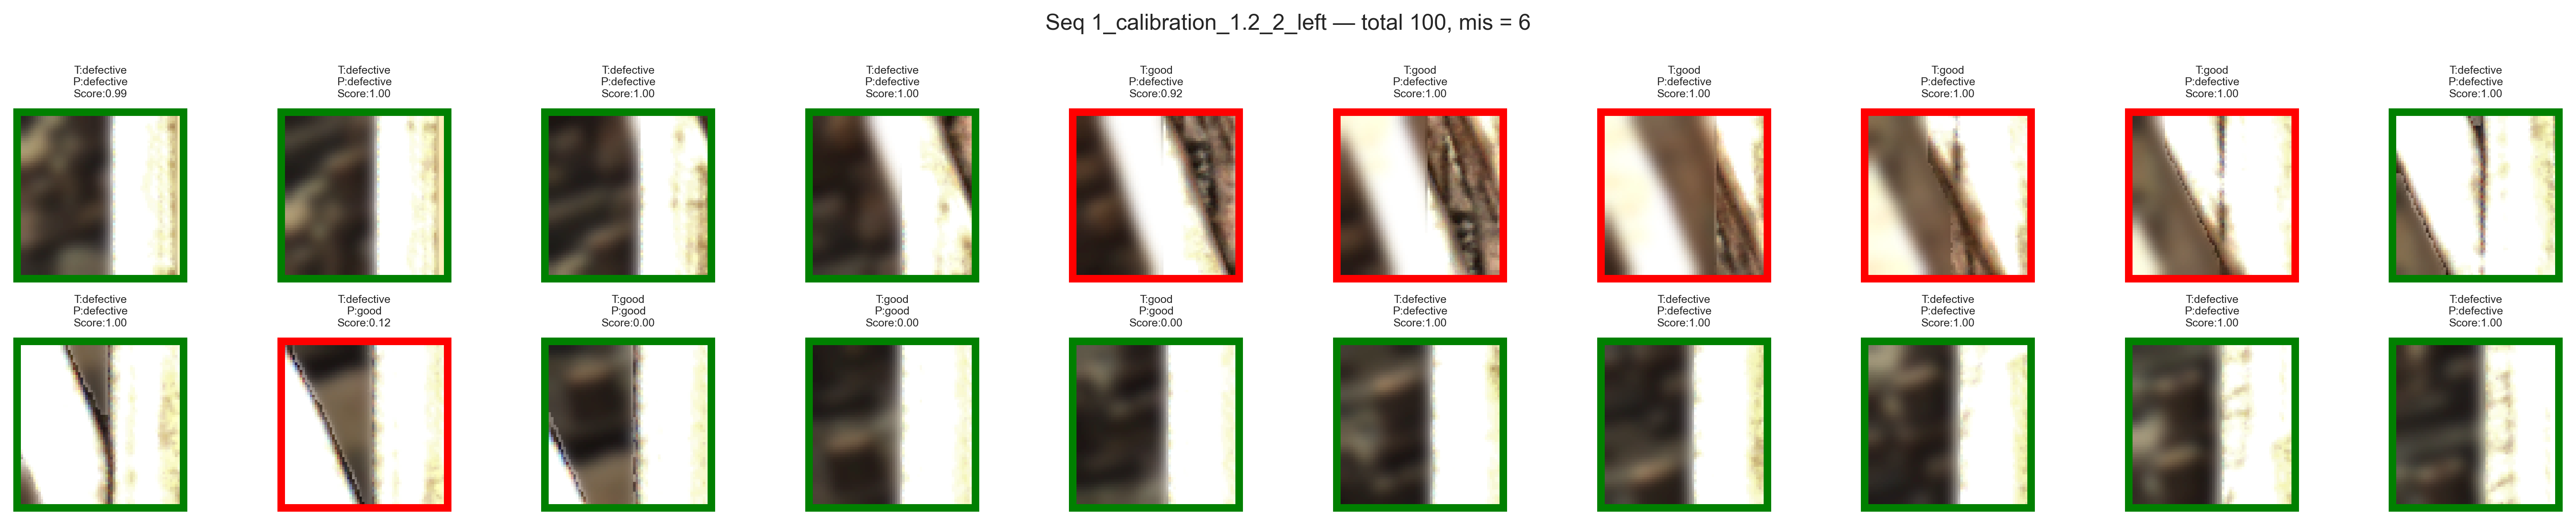

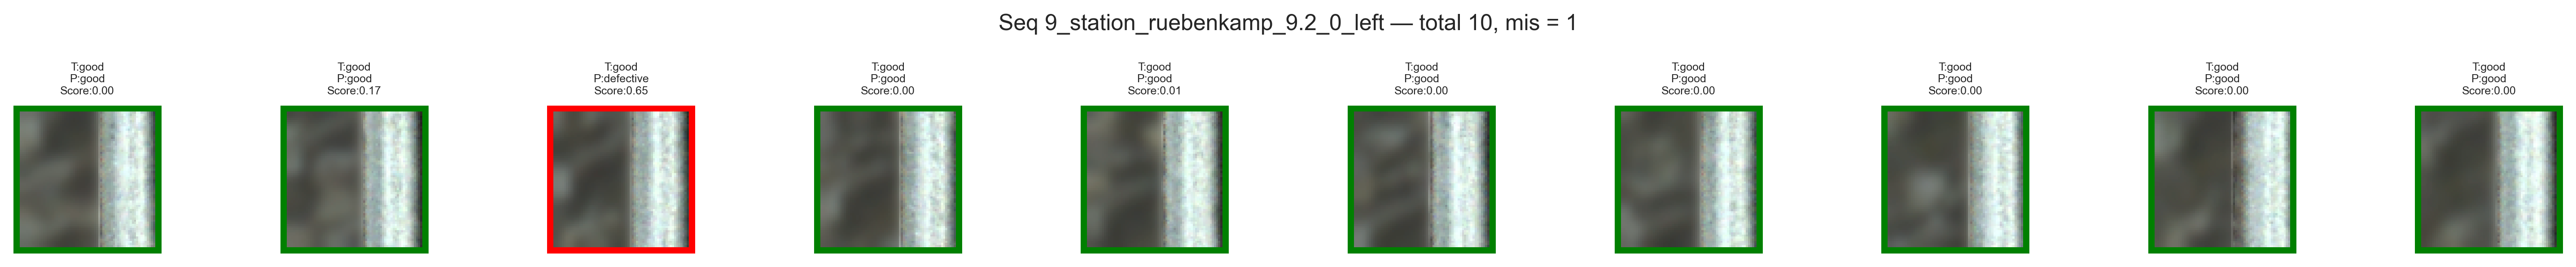

In [12]:
RUN_DIR = Path("results_experiment5_tuning")
VAL_ROOT = Path("./blurclahe_data_folds/blurclahe_inner_seed79/folds/fold_1/val")

pattern = re.compile(
    r'(?P<station>.+?)_'
    r'(?P<image_id>\d+_[0-9\.]+)_patches_patch_'
    r'(?P<x>\d+)_'
    r'(?P<y>\d+)_'
    r'(?P<angle>[0-9\.]+)_'
    r'(?P<track>-?\d+)'
    r'(?:_(?P<side>left|right))?'
    r'(?:\.[^.]+)?$'
)

#Load predictions, metrics, mapping
preds_path = RUN_DIR / "combo13_fold1_val_predictions.csv"
val_df = pd.read_csv(preds_path)

#Attach image paths in same ordering
val_image_paths = []
for cls in ["defective", "good"]:
    cls_dir = VAL_ROOT / cls
    for img_file in sorted(cls_dir.glob("*")):
        if img_file.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]:
            val_image_paths.append(str(img_file))
val_df["image_path"] = val_image_paths


mapping = {
    "class_names": ["defective", "good"],
    "positive_class": "defective",
    "pos_idx": 0
}

class_names   = mapping["class_names"]
positive_cls  = mapping["positive_class"]
pos_idx       = mapping["pos_idx"]


#Print confusion metrics
# print(f"TP: {metrics['tp']} | TN: {metrics['tn']} | FP: {metrics['fp']} | FN: {metrics['fn']}")

#Parse filenames & annotate
def parse_filename(fn):
    m = pattern.search(os.path.basename(fn))
    if not m:
        return None
    d = m.groupdict()
    d["station_track_side"] = f"{d['station']}_{d['track']}_{d.get('side','')}"
    # also capture image_id so we can sort
    d["image_id"] = d.get("image_id")
    return d

meta_df = pd.DataFrame([parse_filename(p) for p in val_df["image_path"]])
val_df = pd.concat([val_df, meta_df], axis=1)
val_df.dropna(subset=["station_track_side"], inplace=True)

val_df["is_misclassified"] = val_df["y_true"] != val_df["y_pred"]
val_df["true_label"] = val_df["y_true"].apply(lambda x: class_names[x])
val_df["pred_label"] = val_df["y_pred"].apply(lambda x: class_names[x])
val_df["defective_score"] = val_df["p_class_0"]

#New plot function for Deit sequences with skip blank rows
def plot_sequence_skip(seq_df, seq_id, patches_per_row=10):
    # Must sort by image_id (string or numeric) so patches in correct order
    seq_df = seq_df.sort_values("image_id")
    if not seq_df["is_misclassified"].any():
        return

    total = len(seq_df)
    miscount = int(seq_df["is_misclassified"].sum())
    n_rows_all = (total + patches_per_row - 1) // patches_per_row

    # Determine which row indices to actually plot (those containing at least one mis)
    keep_rows = []
    for r in range(n_rows_all):
        start = r * patches_per_row
        end = min((r + 1) * patches_per_row, total)
        row_slice = seq_df.iloc[start:end]
        if row_slice["is_misclassified"].any():
            keep_rows.append(r)

    if not keep_rows:
        return

    n_rows = len(keep_rows)
    fig, axes = plt.subplots(n_rows, patches_per_row,
                              figsize=(2 * patches_per_row, 2 * n_rows),
                              squeeze=False)
    fig.suptitle(f"Seq {seq_id} — total {total}, mis = {miscount}", fontsize=12)

    for plot_row_idx, r in enumerate(keep_rows):
        start = r * patches_per_row
        end = min((r + 1) * patches_per_row, total)
        for c in range(patches_per_row):
            ax = axes[plot_row_idx, c]
            idx_global = start + c
            if idx_global >= total:
                ax.axis("off")
                continue
            row = seq_df.iloc[idx_global]
            img_path = row.image_path
            if not os.path.isfile(img_path):
                ax.axis("off")
                continue
            img = Image.open(img_path).convert("RGB")
            border = "red" if row.is_misclassified else "green"
            bordered = ImageOps.expand(img, border=3, fill=border)
            ax.imshow(bordered)
            ax.axis("off")
            title = f"T:{row.true_label}\nP:{row.pred_label}\nScore:{row.defective_score:.2f}"
            ax.set_title(title, fontsize=6)

    plt.tight_layout()
    plt.show()


#Run for each sequence
for seq_id, grp in val_df.groupby("station_track_side"):
    plot_sequence_skip(grp, seq_id)


### for fold 1 (2 for report)

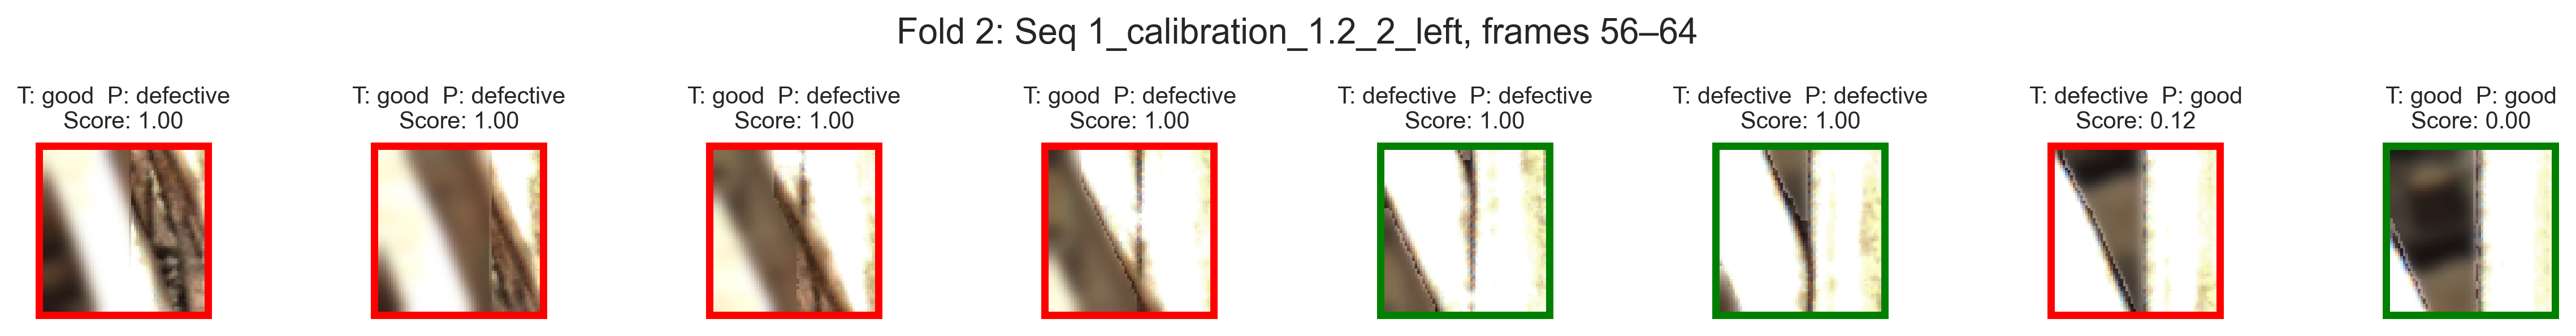

In [13]:
def plot_frames_range_for_sequence(val_df, seq_id,
                                   start_idx=6, end_idx=13,
                                   patches_per_row=8, figsize=(2*8, 2)):
    """
    Plot frames from start_idx to end_idx (inclusive) for a given sequence seq_id.
    """
    grp = val_df[val_df["station_track_side"] == seq_id]
    grp_sorted = grp.sort_values("image_id").reset_index(drop=True)
    # Select only the slice of interest
    sel = grp_sorted.iloc[(start_idx-1):end_idx]
    if sel.empty:
        print(f"No frames in range {start_idx}-{end_idx} for sequence {seq_id}")
        return
    
    total = len(sel)
    n_cols = min(total, patches_per_row)
    fig, axes = plt.subplots(1, n_cols, figsize=(figsize[0], figsize[1]))
    fig.suptitle(f"Fold 2: Seq {seq_id}, frames {start_idx}–{end_idx}", fontsize=15)
    if n_cols == 1:
        axes = [axes]
    
    for ax_idx, (_, row) in zip(range(n_cols), sel.iterrows()):
        ax = axes[ax_idx]
        img_path = row.image_path
        if not os.path.isfile(img_path):
            ax.axis("off")
            continue
        img = Image.open(img_path).convert("RGB")
        border = "red" if row.is_misclassified else "green"
        bordered = ImageOps.expand(img, border=3, fill=border)
        ax.imshow(bordered)
        ax.axis("off")
        ax.set_title(
            f"T: {row.true_label}  P: {row.pred_label}\nScore: {row.defective_score:.2f}",
            fontsize=10
        )
    
    plt.tight_layout()
    plt.savefig("fold1_frames.png", dpi=300, bbox_inches="tight")
    plt.show()


seq_id = "1_calibration_1.2_2_left"
plot_frames_range_for_sequence(val_df, seq_id, start_idx=56, end_idx=64,
                               patches_per_row=8, figsize=(16,2))


### For fold 2 and 4 (3 and 5 for report)

In [14]:
RUN_DIR = Path("results_experiment5_tuning")
VAL_ROOT = Path("./blurclahe_data_folds/blurclahe_inner_seed79/folds/fold_2/val")
#Load predictions, metrics, mapping
preds_path = RUN_DIR / "combo13_fold2_val_predictions.csv"
val_df = pd.read_csv(preds_path)
#Attach image paths in same ordering
val_image_paths = []
for cls in ["defective", "good"]:
    cls_dir = VAL_ROOT / cls
    for img_file in sorted(cls_dir.glob("*")):
        if img_file.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]:
            val_image_paths.append(str(img_file))
val_df["image_path"] = val_image_paths
mapping = {
    "class_names": ["defective", "good"],
    "positive_class": "defective",
    "pos_idx": 0
}
class_names   = mapping["class_names"]
positive_cls  = mapping["positive_class"]
pos_idx       = mapping["pos_idx"]
meta_df = pd.DataFrame([parse_filename(p) for p in val_df["image_path"]])
val_df = pd.concat([val_df, meta_df], axis=1)
val_df.dropna(subset=["station_track_side"], inplace=True)
val_df["is_misclassified"] = val_df["y_true"] != val_df["y_pred"]
val_df["true_label"] = val_df["y_true"].apply(lambda x: class_names[x])
val_df["pred_label"] = val_df["y_pred"].apply(lambda x: class_names[x])
val_df["defective_score"] = val_df["p_class_0"]


Saved figure: fold3final_1x4_selected.png


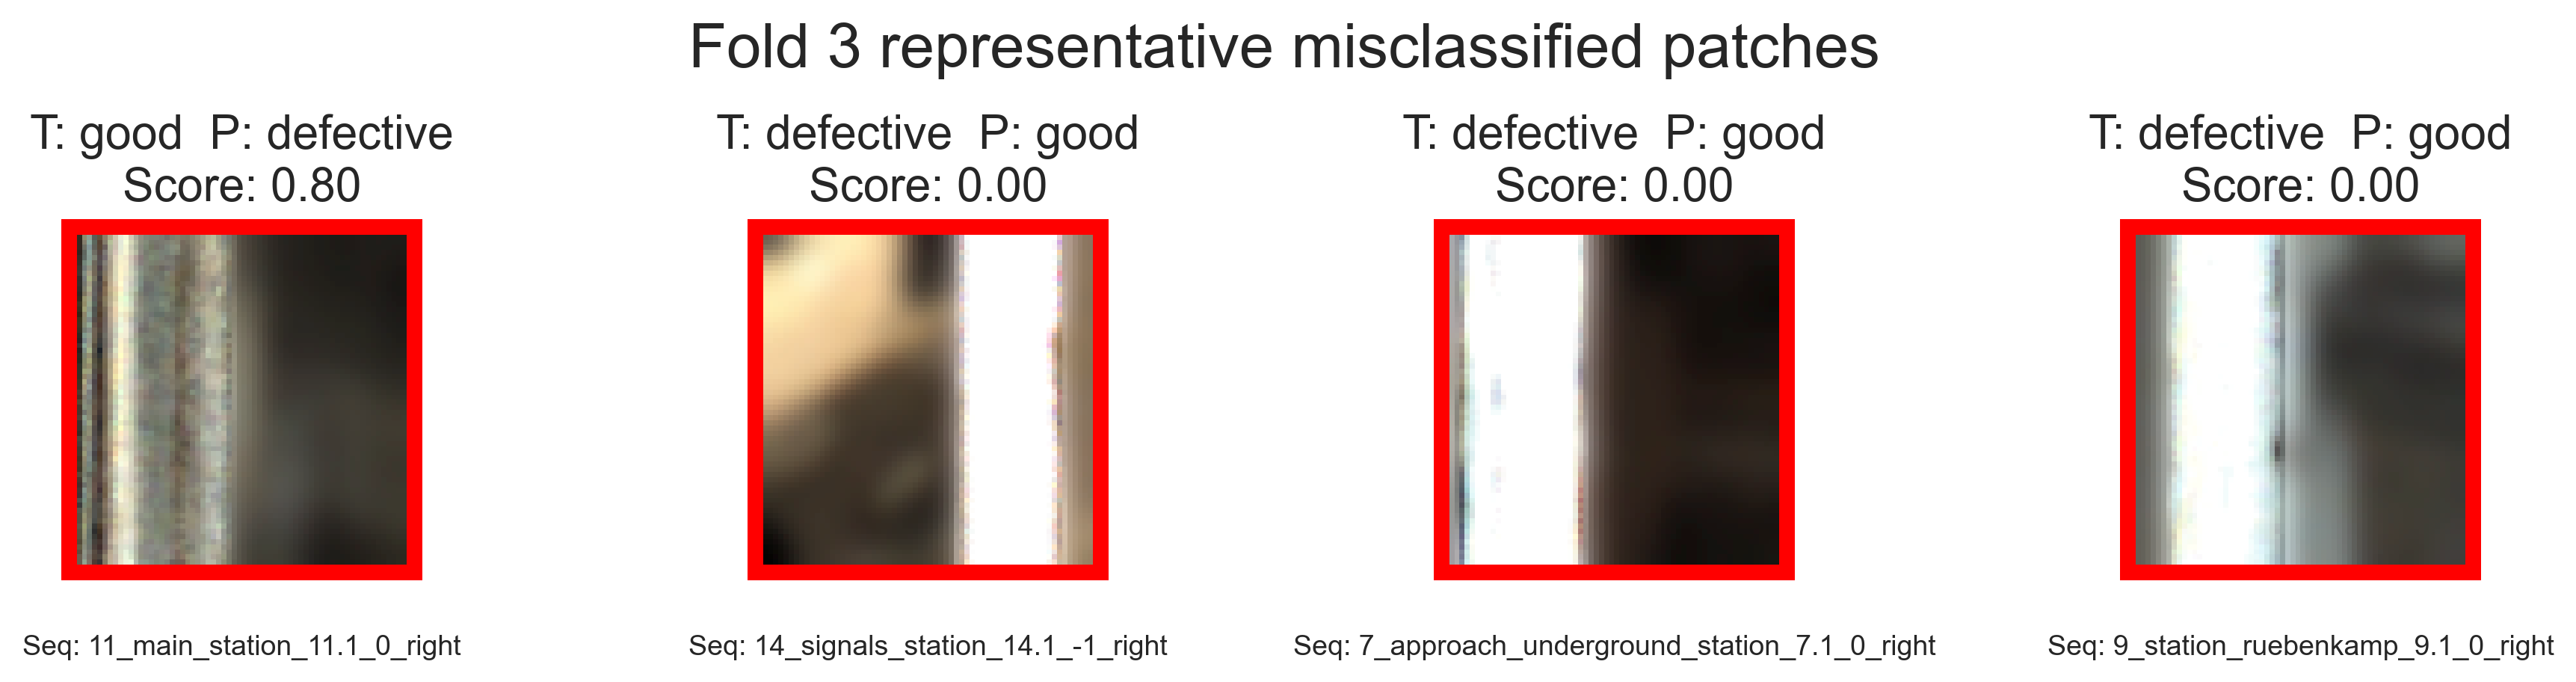

In [15]:
def plot_selected_sequences(val_df, selected_seqs, save_path="selected_misclassified.png",
                            figsize=(12, 3), title_fs=20, top_text_fs=15, seq_text_fs=9):
    """
    Plot the first mis-classified patch for each sequence in `selected_seqs`
    in a single row (1×len(selected_seqs)), and save the figure.
    """
    n = len(selected_seqs)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    fig.suptitle("Fold 3 representative misclassified patches", fontsize=title_fs)

    if n == 1:
        axes = [axes]

    for ax_idx, seq_id in enumerate(selected_seqs):
        ax = axes[ax_idx]
        grp = val_df[val_df["station_track_side"] == seq_id]
        grp_sorted = grp.sort_values("image_id")
        mis_df = grp_sorted[grp_sorted["is_misclassified"]]
        if mis_df.empty:
            ax.axis("off")
            continue
        row = mis_df.iloc[0]
        img_path = row.image_path
        if not os.path.isfile(img_path):
            ax.axis("off")
            continue

        img = Image.open(img_path).convert("RGB")
        bordered = ImageOps.expand(img, border=3, fill="red")
        ax.imshow(bordered)
        ax.axis("off")

        ax.set_title(
            f"T: {row.true_label}  P: {row.pred_label}\nScore: {row.defective_score:.2f}",
            fontsize=top_text_fs
        )
        ax.text(
            0.5, -0.15,
            f"Seq: {seq_id}",
            fontsize=seq_text_fs,
            ha='center',
            va='top',
            transform=ax.transAxes
        )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {save_path}")
    plt.show()


#List of sequences
# selected_sequences = [
#     "13_station_ohlsdorf_13.1_0_right",
#     "14_signals_station_14.1_0_left",
#     "2_station_berliner_tor_2.1_0_left",
#     "5_station_bergedorf_5.1_0_left"
# ]

selected_sequences = [
    "11_main_station_11.1_0_right",
    "14_signals_station_14.1_-1_right",
    "7_approach_underground_station_7.1_0_right",
    "9_station_ruebenkamp_9.1_0_right"
]

plot_selected_sequences(val_df, selected_sequences, save_path="fold3final_1x4_selected.png")


# Train on all folds, test on held out test with best parameters

## Move train and test(from outer split) data to another folder

In [25]:
source_dirs = [
    "./blurclahe_data_folds/outer_5folds_balanced/folds/fold_0/val",
    "./blurclahe_data_folds/outer_5folds_balanced/folds/fold_0/val_masks",

    "./blurclahe_data_folds/outer_5folds_balanced/folds/fold_0/train",
]

target_dirs = [
    "./blurclahe_data_folds/blurclahe_inner_seed79_train_test/test",
    "./blurclahe_data_folds/blurclahe_inner_seed79_train_test/test_masks",

    "./blurclahe_data_folds/blurclahe_inner_seed79_train_test/train"
]

for src, dst in zip(source_dirs, target_dirs):
    os.makedirs(dst, exist_ok=True)

    for item in os.listdir(src):
        src_path = os.path.join(src, item)
        dst_path = os.path.join(dst, item)

        if os.path.isdir(src_path):
            if os.path.exists(dst_path):
                shutil.rmtree(dst_path)  
            shutil.copytree(src_path, dst_path)

print("All folders copied successfully!")


All folders copied successfully!


In [ ]:

# Exp-5: Final Model Training & Evaluation on Held-Out Set E

# Steps:
# 1. Train 3 final models (seeds 0, 42, 123) on 80% train data with best hyperparameters
# 2. Generate predictions on train set (for post-processing tuning if needed)
# 3. Generate predictions on held-out test set E
# 4. Create ensemble predictions (average probabilities across 3 seeds)
# 5. Save all metrics, predictions, and artifacts for post-processing and plotting

# Outputs:
# - final_model_seed{0,42,123}.pt (3 trained models)
# - train_predictions_seed{0,42,123}.csv (predictions on train set)
# - test_predictions_seed{0,42,123}.csv (predictions on test set E)
# - train_predictions_ensemble.csv (ensemble on train)
# - test_predictions_ensemble.csv (ensemble on test)
# - train_metrics_seed{0,42,123}.json (train set metrics per seed)
# - test_metrics_seed{0,42,123}.json (test set metrics per seed)
# - test_metrics_ensemble.json (ensemble metrics on test)
# - training_history_seed{0,42,123}.csv (epoch-by-epoch training logs)
# - confusion_matrices/ (all confusion matrices)


# Best Hyperparameters from Tuning
BEST_HYPERPARAMS = {
    'learning_rate': 0.0004638630972397277,
    'weight_decay': 0.017336465350777208,
    'warmup_epochs': 5,
    'batch_size': 64,
    'epochs': 50,
    'img_size': 224,
    'num_workers': 0,
    'drop_path_rate': 0.1,
}

FINAL_SEEDS = [0, 42, 123]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# Utils
def _merge_logits_for_loss_and_pred(logits):
    if isinstance(logits, tuple):
        cls, dist = logits
        merged = 0.5 * (cls + dist)
        return merged, merged
    return logits, logits

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

def device_str():
    return "cuda" if torch.cuda.is_available() else "cpu"

def print_section(title: str):
    """Print a nice section header."""
    print("\n" + "-"*10)
    print(f"  {title}")
    print("-"*10)

def print_metrics(metrics: Dict, prefix: str = ""):
    """Print metrics in a nice format."""
    print(f"\n{prefix}Metrics:")
    print(f"  Loss: {metrics.get('loss', np.nan):.4f}")
    print(f"  Accuracy: {metrics.get('accuracy', np.nan):.4f}")
    print(f"  Balanced Accuracy: {metrics.get('balanced_accuracy', np.nan):.4f}")
    if 'auprc' in metrics:
        print(f"  AUPRC: {metrics.get('auprc', np.nan):.4f}")
        print(f"  AUROC: {metrics.get('auroc', np.nan):.4f}")
        print(f"  Precision: {metrics.get('precision', np.nan):.4f}")
        print(f"  Recall: {metrics.get('recall', np.nan):.4f}")
        print(f"  F1: {metrics.get('f1', np.nan):.4f}")
        print(f"  Confusion Matrix: TP={metrics.get('tp', 0)}, TN={metrics.get('tn', 0)}, "
              f"FP={metrics.get('fp', 0)}, FN={metrics.get('fn', 0)}")


# Data
def build_transforms(img_size: int):
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([transforms.ColorJitter(0.1, 0.1, 0.1, 0.02)], p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return train_tf, eval_tf

def build_dataloaders(train_dir: Path, test_dir: Path, batch_size: int, 
                      img_size: int, num_workers: int):
    """Build train and test dataloaders."""
    if not train_dir.exists():
        raise FileNotFoundError(f"Train directory not found: {train_dir}")
    if not test_dir.exists():
        raise FileNotFoundError(f"Test directory not found: {test_dir}")
    
    train_tf, eval_tf = build_transforms(img_size)
    
    train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
    test_ds = datasets.ImageFolder(test_dir, transform=eval_tf)
    
    print(f"\nDataset Statistics:")
    print(f"  Train samples: {len(train_ds)}")
    print(f"  Test samples: {len(test_ds)}")
    print(f"  Classes: {train_ds.classes}")
    
    # Print class distribution
    train_targets = [label for _, label in train_ds.samples]
    test_targets = [label for _, label in test_ds.samples]
    train_counts = np.bincount(train_targets)
    test_counts = np.bincount(test_targets)
    
    print(f"\n  Train class distribution:")
    for i, class_name in enumerate(train_ds.classes):
        print(f"    {class_name}: {train_counts[i]} ({100*train_counts[i]/len(train_ds):.1f}%)")
    
    print(f"\n  Test class distribution:")
    for i, class_name in enumerate(test_ds.classes):
        print(f"    {class_name}: {test_counts[i]} ({100*test_counts[i]/len(test_ds):.1f}%)")
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                             num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True)
    
    return train_loader, test_loader, train_ds.classes, train_ds, test_ds


# Model
def build_deit_small(num_classes: int, drop_path_rate: float = 0.1):
    model = timm.create_model(
        "deit_small_patch16_224",
        pretrained=True,
        num_classes=num_classes,
        drop_path_rate=drop_path_rate,
    )
    return model

def make_optimizer(model: nn.Module, hp: Dict):
    params = [p for p in model.parameters() if p.requires_grad]
    scaled_lr = hp['learning_rate'] * (hp['batch_size'] / 256.0)
    return optim.AdamW(params, lr=scaled_lr, weight_decay=hp['weight_decay'])

def make_warmup_cosine_scheduler(optimizer, hp: Dict, steps_per_epoch: int):
    total_steps = hp['epochs'] * steps_per_epoch
    warmup_steps = hp['warmup_epochs'] * steps_per_epoch
    
    def lr_lambda(step):
        if step < warmup_steps and warmup_steps > 0:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


# Train / Eval
def train_one_epoch(model, loader, device, criterion, optimizer, epoch: int, total_epochs: int):
    model.train()
    losses, correct, total = [], 0, 0
    
    pbar = _tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Train]", leave=False)
    for images, targets in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss_logits, pred_logits = _merge_logits_for_loss_and_pred(logits)
        loss = criterion(loss_logits, targets)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        with torch.no_grad():
            preds = pred_logits.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
        
        pbar.set_postfix({'loss': f"{np.mean(losses):.4f}", 'acc': f"{correct/total:.4f}"})
    
    return float(np.mean(losses)), correct / max(1, total)

@torch.no_grad()
def evaluate_with_predictions(model, loader, device, criterion, class_names: List[str],
                               dataset, split_name: str = "eval"):
    """Evaluate and return detailed predictions with filenames."""
    model.eval()
    losses, all_targets, all_probs, all_preds, all_filenames = [], [], [], [], []
    
    pbar = _tqdm(loader, desc=f"Evaluating [{split_name}]", leave=False)
    sample_idx = 0
    
    for images, targets in pbar:
        batch_size = targets.size(0)
        
        # Get filenames for this batch
        batch_filenames = [os.path.basename(dataset.samples[sample_idx + i][0]) 
                          for i in range(batch_size)]
        sample_idx += batch_size
        all_filenames.extend(batch_filenames)
        
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        
        logits = model(images)
        loss_logits, pred_logits = _merge_logits_for_loss_and_pred(logits)
        loss = criterion(loss_logits, targets)
        losses.append(loss.item())
        
        probs = torch.softmax(pred_logits, dim=1)
        preds = probs.argmax(dim=1)
        
        all_targets.append(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        
        pbar.set_postfix({'loss': f"{np.mean(losses):.4f}"})
    
    y_true = np.concatenate(all_targets)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)
    filenames = np.array(all_filenames)
    
    # Compute metrics
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    metrics = {
        "loss": float(np.mean(losses)),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
    }
    
    # Binary classification metrics
    if len(class_names) == 2:
        try:
            pos_idx = class_names.index("defective")
        except:
            pos_idx = 1
        
        y_true_bin = (y_true == pos_idx).astype(int)
        y_pred_bin = (y_pred == pos_idx).astype(int)
        
        try:
            auroc = roc_auc_score(y_true_bin, y_prob[:, pos_idx])
        except:
            auroc = np.nan
        
        try:
            auprc = average_precision_score(y_true_bin, y_prob[:, pos_idx])
        except:
            auprc = np.nan
        
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_bin, y_pred_bin, average="binary", zero_division=0
        )
        
        cm = confusion_matrix(y_true_bin, y_pred_bin)
        tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)
        
        metrics.update({
            "auroc": float(auroc),
            "auprc": float(auprc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        })
    
    return metrics, y_true, y_pred, y_prob, filenames


# Main Training Loop
def train_final_model(train_loader, test_loader, train_dataset, test_dataset,
                     class_names, hp: Dict, seed: int, out_dir: Path, device: str):
    """Train a single final model with given seed."""
    
    print_section(f"Training Final Model (Seed {seed})")
    set_seed(seed)
    
    num_classes = len(class_names)
    
    # Build model
    print(f"\nBuilding DeiT-Small model...")
    model = build_deit_small(num_classes, hp['drop_path_rate']).to(device)
    n_params = count_params(model)
    print(f"  Model parameters: {n_params:,}")

    # Compute class weights from training set
    train_targets = [label for _, label in train_dataset.samples]
    class_counts = np.bincount(train_targets, minlength=num_classes)
    class_weights = class_counts.max() / np.clip(class_counts, 1, None)
    print(f"\nClass weights: {class_weights}")
    
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
    )
    
    # Optimizer & scheduler
    optimizer = make_optimizer(model, hp)
    scheduler = make_warmup_cosine_scheduler(optimizer, hp, steps_per_epoch=len(train_loader))
    
    scaled_lr = hp['learning_rate'] * (hp['batch_size'] / 256.0)
    print(f"\nTraining Configuration:")
    print(f"  Base LR: {hp['learning_rate']:.6f}")
    print(f"  Scaled LR: {scaled_lr:.6f}")
    print(f"  Weight Decay: {hp['weight_decay']:.6f}")
    print(f"  Warmup Epochs: {hp['warmup_epochs']}")
    print(f"  Total Epochs: {hp['epochs']}")
    print(f"  Batch Size: {hp['batch_size']}")
    
    # Training loop
    history = []

    print(f"\nStarting training...")
    for epoch in range(hp['epochs']):
        # Train
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, device, criterion, optimizer, epoch, hp['epochs']
        )
        scheduler.step()
        
        # Evaluate on training set (for monitoring only, not for model selection)
        train_metrics, _, _, _, _ = evaluate_with_predictions(
            model, train_loader, device, criterion, class_names, train_dataset, "train"
        )
        
        # Log
        row = {
            'epoch': epoch,
            'train_loss': tr_loss,
            'train_acc': tr_acc,
            'train_loss_eval': train_metrics['loss'],
            'train_accuracy_eval': train_metrics['accuracy'],
            'train_balanced_accuracy': train_metrics['balanced_accuracy'],
            'train_auprc': train_metrics.get('auprc', np.nan),
            'train_auroc': train_metrics.get('auroc', np.nan),
            'train_precision': train_metrics.get('precision', np.nan),
            'train_recall': train_metrics.get('recall', np.nan),
            'train_f1': train_metrics.get('f1', np.nan),
            'train_tp': train_metrics.get('tp', 0),
            'train_tn': train_metrics.get('tn', 0),
            'train_fp': train_metrics.get('fp', 0),
            'train_fn': train_metrics.get('fn', 0),
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(row)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 1 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{hp['epochs']}:")
            print(f"    Train Loss={tr_loss:.4f}, Acc={tr_acc:.4f}, LR={optimizer.param_groups[0]['lr']:.2e}")
            print(f"    Train AUPRC={train_metrics.get('auprc', np.nan):.4f}, "
                f"Prec={train_metrics.get('precision', np.nan):.4f}, "
                f"Rec={train_metrics.get('recall', np.nan):.4f}, "
                f"F1={train_metrics.get('f1', np.nan):.4f}")
            print(f"    TP={train_metrics.get('tp', 0)}, TN={train_metrics.get('tn', 0)}, "
                f"FP={train_metrics.get('fp', 0)}, FN={train_metrics.get('fn', 0)}")
                
    print(f"\n Training complete!")
    print(f"  Final train loss: {tr_loss:.4f}")
    print(f"  Final train accuracy: {tr_acc:.4f}")

    # Save training history
    history_df = pd.DataFrame(history)
    history_path = out_dir / f"training_history_seed{seed}.csv"
    history_df.to_csv(history_path, index=False)
    print(f"  Saved training history: {history_path}")

    # Save final model (epoch 50)
    torch.save(model.state_dict(), out_dir / f"final_model_seed{seed}.pt")
    print(f"  Saved final model: final_model_seed{seed}.pt")
    
    return model, class_names

# Generate & Save Predictions
def generate_and_save_predictions(model, loader, dataset, class_names, device, 
                                 out_path: Path, split_name: str, seed: int):
    """Generate predictions and save to CSV with filenames."""
    
    print(f"\nGenerating predictions for {split_name} set (seed {seed})...")
    
    criterion = nn.CrossEntropyLoss()  # Dummy, we only need predictions
    metrics, y_true, y_pred, y_prob, filenames = evaluate_with_predictions(
        model, loader, device, criterion, class_names, dataset, split_name
    )
    
    # Create DataFrame
    df = pd.DataFrame({
        'filename': filenames,
        'y_true': y_true,
        'y_pred': y_pred,
    })
    
    # Add probability columns
    for c in range(len(class_names)):
        df[f'p_class_{c}'] = y_prob[:, c]
    
    # Save
    df.to_csv(out_path, index=False)
    print(f"  Saved {len(df)} predictions to: {out_path}")
    
    # Print metrics
    print_metrics(metrics, prefix=f"  {split_name.capitalize()} ")
    
    # Save metrics
    metrics_path = out_path.parent / f"{split_name}_metrics_seed{seed}.json"
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)
    print(f"  Saved metrics to: {metrics_path}")
    
    # Save confusion matrix
    if len(class_names) == 2:
        try:
            pos_idx = class_names.index("defective")
        except:
            pos_idx = 1
        
        y_true_bin = (y_true == pos_idx).astype(int)
        y_pred_bin = (y_pred == pos_idx).astype(int)
        
        cm = confusion_matrix(y_true_bin, y_pred_bin)
        cm_df = pd.DataFrame(cm, 
                            index=['True Negative', 'True Positive'],
                            columns=['Pred Negative', 'Pred Positive'])
        
        cm_path = out_path.parent / "confusion_matrices" / f"{split_name}_confusion_matrix_seed{seed}.csv"
        cm_path.parent.mkdir(exist_ok=True)
        cm_df.to_csv(cm_path)
        print(f"  Saved confusion matrix to: {cm_path}")
    
    return metrics, df

# Ensemble Predictions
def create_ensemble_predictions(pred_dfs: List[pd.DataFrame], out_path: Path, 
                               split_name: str, class_names: List[str]):
    """Ensemble predictions by averaging probabilities across seeds."""
    
    print(f"\nCreating ensemble predictions for {split_name} set...")
    
    # Verify all DataFrames have same filenames in same order
    filenames = pred_dfs[0]['filename'].values
    for i, df in enumerate(pred_dfs[1:], 1):
        if not np.array_equal(df['filename'].values, filenames):
            raise ValueError(f"Filename mismatch between seed 0 and seed {i}")
    
    print(f" Verified {len(filenames)} filenames match across all seeds")
    
    # Average probabilities
    num_classes = len(class_names)
    ensemble_probs = np.zeros((len(filenames), num_classes))
    
    for df in pred_dfs:
        for c in range(num_classes):
            ensemble_probs[:, c] += df[f'p_class_{c}'].values
    
    ensemble_probs /= len(pred_dfs)
    
    # Get predictions from ensemble probabilities
    ensemble_preds = ensemble_probs.argmax(axis=1)
    y_true = pred_dfs[0]['y_true'].values
    
    # Create DataFrame
    ensemble_df = pd.DataFrame({
        'filename': filenames,
        'y_true': y_true,
        'y_pred': ensemble_preds,
    })
    
    for c in range(num_classes):
        ensemble_df[f'p_class_{c}'] = ensemble_probs[:, c]
    
    # Save
    ensemble_df.to_csv(out_path, index=False)
    print(f" Saved ensemble predictions to: {out_path}")
    
    # Compute metrics
    acc = accuracy_score(y_true, ensemble_preds)
    bal_acc = balanced_accuracy_score(y_true, ensemble_preds)
    
    metrics = {
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
    }
    
    if len(class_names) == 2:
        try:
            pos_idx = class_names.index("defective")
        except:
            pos_idx = 1
        
        y_true_bin = (y_true == pos_idx).astype(int)
        y_pred_bin = (ensemble_preds == pos_idx).astype(int)
        
        try:
            auroc = roc_auc_score(y_true_bin, ensemble_probs[:, pos_idx])
        except:
            auroc = np.nan
        
        try:
            auprc = average_precision_score(y_true_bin, ensemble_probs[:, pos_idx])
        except:
            auprc = np.nan
        
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_bin, y_pred_bin, average="binary", zero_division=0
        )
        
        cm = confusion_matrix(y_true_bin, y_pred_bin)
        tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)
        
        metrics.update({
            "auroc": float(auroc),
            "auprc": float(auprc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        })
    
    print_metrics(metrics, prefix="  Ensemble ")
    
    # Save metrics
    metrics_path = out_path.parent / f"{split_name}_metrics_ensemble.json"
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)
    print(f" Saved ensemble metrics to: {metrics_path}")
    
    # Save confusion matrix
    if len(class_names) == 2:
        cm_df = pd.DataFrame(cm, 
                            index=['True Negative', 'True Positive'],
                            columns=['Pred Negative', 'Pred Positive'])
        cm_path = out_path.parent / "confusion_matrices" / f"{split_name}_confusion_matrix_ensemble.csv"
        cm_path.parent.mkdir(exist_ok=True)
        cm_df.to_csv(cm_path)
        print(f" Saved confusion matrix to: {cm_path}")
    
    return metrics, ensemble_df

# Main Experiment 5
def run_experiment_5(train_dir: str, test_dir: str, out_dir: str, device: Optional[str] = None):
    """
    Main Experiment 5: Train final models and evaluate on held-out test set.
    
    Steps:
    1. Train 3 models with seeds [0, 42, 123] using best hyperparameters
    2. Generate predictions on train and test sets for each seed
    3. Create ensemble predictions by averaging probabilities
    4. Save all results for post-processing and analysis
    """
    
    device = device or device_str()
    print_section("EXPERIMENT 5: FINAL MODEL TRAINING & EVALUATION")
    print(f"\nConfiguration:")
    print(f"  Device: {device}")
    print(f"  Train dir: {train_dir}")
    print(f"  Test dir: {test_dir}")
    print(f"  Output dir: {out_dir}")
    print(f"  Seeds: {FINAL_SEEDS}")
    
    # Create output directory
    out_root = Path(out_dir)
    out_root.mkdir(parents=True, exist_ok=True)
    (out_root / "confusion_matrices").mkdir(exist_ok=True)
    
    # Save hyperparameters
    hp_path = out_root / "best_hyperparameters.json"
    with open(hp_path, "w") as f:
        json.dump(BEST_HYPERPARAMS, f, indent=2)
    print(f"\nSaved hyperparameters to: {hp_path}")
    
    # Load data
    print_section("Loading Data")
    train_loader, test_loader, class_names, train_dataset, test_dataset = build_dataloaders(
        Path(train_dir), Path(test_dir), 
        BEST_HYPERPARAMS['batch_size'],
        BEST_HYPERPARAMS['img_size'],
        BEST_HYPERPARAMS['num_workers']
    )
    
    # Save class mapping
    class_mapping = {
        "class_names": class_names,
        "positive_class": "defective" if "defective" in class_names else class_names[-1],
        "pos_idx": int(class_names.index("defective")) if "defective" in class_names else 1
    }
    with open(out_root / "class_mapping.json", "w") as f:
        json.dump(class_mapping, f, indent=2)
    
    # Train models for each seed
    train_pred_dfs = []
    test_pred_dfs = []
    
    for seed in FINAL_SEEDS:
        # Train model
        model, _ = train_final_model(
            train_loader, test_loader, train_dataset, test_dataset,
            class_names, BEST_HYPERPARAMS, seed, out_root, device
        )
        
        # Generate predictions on train set
        print_section(f"Generating Train Predictions (Seed {seed})")
        train_metrics, train_df = generate_and_save_predictions(
            model, train_loader, train_dataset, class_names, device,
            out_root / f"train_predictions_seed{seed}.csv",
            "train", seed
        )
        train_pred_dfs.append(train_df)
        
        # Generate predictions on test set
        print_section(f"Generating Test Predictions (Seed {seed})")
        test_metrics, test_df = generate_and_save_predictions(
            model, test_loader, test_dataset, class_names, device,
            out_root / f"test_predictions_seed{seed}.csv",
            "test", seed
        )
        test_pred_dfs.append(test_df)
    
    # Create ensemble predictions
    print_section("Creating Ensemble Predictions")
    
    train_ensemble_metrics, train_ensemble_df = create_ensemble_predictions(
        train_pred_dfs, out_root / "train_predictions_ensemble.csv",
        "train", class_names
    )
    
    test_ensemble_metrics, test_ensemble_df = create_ensemble_predictions(
        test_pred_dfs, out_root / "test_predictions_ensemble.csv",
        "test", class_names
    )
    
    # Summary report
    print_section("EXPERIMENT 5 SUMMARY")
    
    print("\nIndividual Seed Performance on Test Set:")
    print(f"\n{'Seed':<10} {'AUPRC':<10} {'Precision':<12} {'Recall':<10} {'F1':<10} {'Accuracy':<10}")
    print("-" * 10)
    
    for seed in FINAL_SEEDS:
        metrics_path = out_root / f"test_metrics_seed{seed}.json"
        with open(metrics_path) as f:
            metrics = json.load(f)
        print(f"{seed:<10} {metrics['auprc']:<10.4f} {metrics['precision']:<12.4f} "
              f"{metrics['recall']:<10.4f} {metrics['f1']:<10.4f} {metrics['accuracy']:<10.4f}")
    
    print("\nEnsemble Performance on Test Set:")
    print(f"  AUPRC: {test_ensemble_metrics['auprc']:.4f}")
    print(f"  AUROC: {test_ensemble_metrics['auroc']:.4f}")
    print(f"  Precision: {test_ensemble_metrics['precision']:.4f}")
    print(f"  Recall: {test_ensemble_metrics['recall']:.4f}")
    print(f"  F1: {test_ensemble_metrics['f1']:.4f}")
    print(f"  Accuracy: {test_ensemble_metrics['accuracy']:.4f}")
    print(f"  Confusion Matrix: TP={test_ensemble_metrics['tp']}, "
          f"TN={test_ensemble_metrics['tn']}, "
          f"FP={test_ensemble_metrics['fp']}, "
          f"FN={test_ensemble_metrics['fn']}")
    
    # Compute mean ± std across seeds
    all_seed_metrics = []
    for seed in FINAL_SEEDS:
        metrics_path = out_root / f"test_metrics_seed{seed}.json"
        with open(metrics_path) as f:
            all_seed_metrics.append(json.load(f))
    
    mean_std_metrics = {}
    for key in ['auprc', 'auroc', 'precision', 'recall', 'f1', 'accuracy', 'tp', 'tn', 'fp', 'fn']:
        values = [m[key] for m in all_seed_metrics]
        mean_std_metrics[f'{key}_mean'] = float(np.mean(values))
        mean_std_metrics[f'{key}_std'] = float(np.std(values))
    
    with open(out_root / "test_metrics_seeds_summary.json", "w") as f:
        json.dump(mean_std_metrics, f, indent=2)
    
    print("\nMean ± Std across Seeds (Test Set):")
    print(f"  AUPRC: {mean_std_metrics['auprc_mean']:.4f} ± {mean_std_metrics['auprc_std']:.4f}")
    print(f"  Precision: {mean_std_metrics['precision_mean']:.4f} ± {mean_std_metrics['precision_std']:.4f}")
    print(f"  Recall: {mean_std_metrics['recall_mean']:.4f} ± {mean_std_metrics['recall_std']:.4f}")
    print(f"  F1: {mean_std_metrics['f1_mean']:.4f} ± {mean_std_metrics['f1_std']:.4f}")
    
    print("\n" + "-"*10)
    print("EXPERIMENT 5 COMPLETE!")
    print("-"*10)
    
    print(f"\nAll results saved to: {out_root}/")
    print(f"\nKey output files:")
    print(f"  Models:")
    for seed in FINAL_SEEDS:
        print(f"    - final_model_seed{seed}.pt")
    print(f"\n  Train Predictions:")
    for seed in FINAL_SEEDS:
        print(f"    - train_predictions_seed{seed}.csv")
    print(f"    - train_predictions_ensemble.csv")
    print(f"\n  Test Predictions:")
    for seed in FINAL_SEEDS:
        print(f"    - test_predictions_seed{seed}.csv")
    print(f"    - test_predictions_ensemble.csv")
    print(f"\n  Metrics:")
    for seed in FINAL_SEEDS:
        print(f"    - train_metrics_seed{seed}.json")
        print(f"    - test_metrics_seed{seed}.json")
    print(f"    - train_metrics_ensemble.json")
    print(f"    - test_metrics_ensemble.json")
    print(f"    - test_metrics_seeds_summary.json")
    print(f"\n  Training History:")
    for seed in FINAL_SEEDS:
        print(f"    - training_history_seed{seed}.csv")
    print(f"\n  Confusion Matrices:")
    print(f"    - confusion_matrices/")
    
    print(f"\nNext steps:")
    print(f"  1. Apply post-processing to ensemble predictions")
    print(f"  2. Perform threshold analysis")
    print(f"  3. Generate visualizations for paper")
    print(f"  4. Run Experiment 6 (XAI analysis)")
    
    return {
        'train_ensemble_metrics': train_ensemble_metrics,
        'test_ensemble_metrics': test_ensemble_metrics,
        'mean_std_metrics': mean_std_metrics,
    }


# Entry Point
if __name__ == "__main__":
    # Set deterministic behavior
    cudnn.benchmark = False
    cudnn.deterministic = True
    torch.set_num_threads(4)
    
    # Paths
    TRAIN_DIR = "./blurclahe_data_folds/blurclahe_inner_seed79_train_test/train"
    TEST_DIR = "./blurclahe_data_folds/blurclahe_inner_seed79_train_test/test"
    OUT_DIR = "./results_experiment5_trainbestparams"
    
    # Verify paths exist
    if not Path(TRAIN_DIR).exists():
        raise FileNotFoundError(f"Train directory not found: {TRAIN_DIR}")
    if not Path(TEST_DIR).exists():
        raise FileNotFoundError(f"Test directory not found: {TEST_DIR}")
    
    print("\n" + "-"*10)
    print("  EXPERIMENT 5: FINAL MODEL TRAINING & EVALUATION ON SET E")
    print("-"*10)
    print(f"\nStarting experiment with:")
    print(f"  Train: {TRAIN_DIR}")
    print(f"  Test: {TEST_DIR}")
    print(f"  Output: {OUT_DIR}")
    print(f"  Seeds: {FINAL_SEEDS}")
    print(f"  Hyperparameters:")
    for key, val in BEST_HYPERPARAMS.items():
        print(f"    {key}: {val}")
    
    # Run experiment
    results = run_experiment_5(
        train_dir=TRAIN_DIR,
        test_dir=TEST_DIR,
        out_dir=OUT_DIR,
        device="cuda"
    )
    
    print("\n" + "-"*10)
    print("  ALL DONE!")
    print("-"*10)

# Inspect sequences of wrongly classified patches

In [27]:
RUN_DIR = Path("results_experiment5_trainbestparams")
VAL_ROOT = Path("./blurclahe_data_folds/blurclahe_inner_seed79_train_test/test")

pattern = re.compile(
    r'(?P<station>.+?)_'
    r'(?P<image_id>\d+_[0-9\.]+)_patches_patch_'
    r'(?P<x>\d+)_'
    r'(?P<y>\d+)_'
    r'(?P<angle>[0-9\.]+)_'
    r'(?P<track>-?\d+)'
    r'(?:_(?P<side>left|right))?'
    r'(?:\.[^.]+)?$'
)

#Load predictions, metrics, mapping
preds_path = RUN_DIR / "test_predictions_ensemble.csv"
val_df = pd.read_csv(preds_path)

#Attach image paths in same ordering
val_image_paths = []
for cls in ["defective", "good"]:
    cls_dir = VAL_ROOT / cls
    for img_file in sorted(cls_dir.glob("*")):
        if img_file.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]:
            val_image_paths.append(str(img_file))
val_df["image_path"] = val_image_paths


mapping = {
    "class_names": ["defective", "good"],
    "positive_class": "defective",
    "pos_idx": 0
}

class_names   = mapping["class_names"]
positive_cls  = mapping["positive_class"]
pos_idx       = mapping["pos_idx"]


#Print confusion metrics
# print(f"TP: {metrics['tp']} | TN: {metrics['tn']} | FP: {metrics['fp']} | FN: {metrics['fn']}")

#Parse filenames & annotate
def parse_filename(fn):
    m = pattern.search(os.path.basename(fn))
    if not m:
        return None
    d = m.groupdict()
    d["station_track_side"] = f"{d['station']}_{d['track']}_{d.get('side','')}"
    # also capture image_id so we can sort
    d["image_id"] = d.get("image_id")
    return d

meta_df = pd.DataFrame([parse_filename(p) for p in val_df["image_path"]])
val_df = pd.concat([val_df, meta_df], axis=1)
val_df.dropna(subset=["station_track_side"], inplace=True)

val_df["is_misclassified"] = val_df["y_true"] != val_df["y_pred"]
val_df["true_label"] = val_df["y_true"].apply(lambda x: class_names[x])
val_df["pred_label"] = val_df["y_pred"].apply(lambda x: class_names[x])
val_df["defective_score"] = val_df["p_class_0"]

#New plot function for Deit sequences with skip blank rows
def plot_sequence_skip(seq_df, seq_id, patches_per_row=10):
    # Must sort by image_id (string or numeric) so patches in correct order
    seq_df = seq_df.sort_values("image_id")
    if not seq_df["is_misclassified"].any():
        return

    total = len(seq_df)
    miscount = int(seq_df["is_misclassified"].sum())
    n_rows_all = (total + patches_per_row - 1) // patches_per_row

    # Determine which row indices to actually plot (those containing at least one mis)
    keep_rows = []
    for r in range(n_rows_all):
        start = r * patches_per_row
        end = min((r + 1) * patches_per_row, total)
        row_slice = seq_df.iloc[start:end]
        if row_slice["is_misclassified"].any():
            keep_rows.append(r)

    if not keep_rows:
        return

    n_rows = len(keep_rows)
    fig, axes = plt.subplots(n_rows, patches_per_row,
                              figsize=(5 * patches_per_row, 5 * n_rows),
                              squeeze=False)
    fig.suptitle(
            f"Seq {seq_id} - total {total}, mis = {miscount}",
            fontsize=34,y=0.98
        )
    plt.subplots_adjust(top=0.75)

    for plot_row_idx, r in enumerate(keep_rows):
        start = r * patches_per_row
        end = min((r + 1) * patches_per_row, total)
        for c in range(patches_per_row):
            ax = axes[plot_row_idx, c]
            idx_global = start + c
            if idx_global >= total:
                ax.axis("off")
                continue
            row = seq_df.iloc[idx_global]
            img_path = row.image_path
            if not os.path.isfile(img_path):
                ax.axis("off")
                continue
            img = Image.open(img_path).convert("RGB")
            border = "red" if row.is_misclassified else "green"
            bordered = ImageOps.expand(img, border=3, fill=border)
            ax.imshow(bordered)
            ax.axis("off")
            title = f"T:{row.true_label};P:{row.pred_label};\nScore:{row.defective_score:.2f}"
            ax.set_title(title, fontsize=25)

    plt.tight_layout()
    # plt.show()
    out_path = SAVE_DIR / f"{seq_id}.png"
    plt.savefig(out_path, dpi=200)
    plt.close()   
    


#Run for each sequence
SAVE_DIR = Path("sequence_plots")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
for seq_id, grp in val_df.groupby("station_track_side"):
    plot_sequence_skip(grp, seq_id)


# Apply post-processing

In [ ]:

# Exp-5 Post-Processing: Apply Best Methods from Exp 4

# Applies the two best post-processing methods to Exp 5 ensemble predictions:
# 1. MULTISCALE_TUNED (best AUPRC: 0.9356)
# 2. CONF_WEIGHTED_ISO_TUNED (best Precision/F1: 0.8706/0.8822)

# Requires:
# - Exp 4 best hyperparameters (manually extracted from results)
# - Ensemble predictions from Exp 5

# Outputs:
# - test_predictions_ensemble_multiscale.csv
# - test_predictions_ensemble_conf_weighted_iso.csv
# - test_metrics_multiscale.json
# - test_metrics_conf_weighted_iso.json
# - Comparison table and confusion matrices


# CONFIGURATION

# Best hyperparameters from Exp 4 
MULTISCALE_PARAMS = {
    'sigmas': [0.5, 1.0, 2.0]  # best sigmas from Exp 4
}

CONF_WEIGHTED_ISO_PARAMS = {
    'sigma': 0.5,        # best sigma from Exp 4
    'conf_thr': 0.05,     # best conf_thr from Exp 4
    'context': 1         # best context from Exp 4
}

# Filename pattern
FILENAME_PATTERN = re.compile(
    r'(?P<station>.+?)_'
    r'(?P<image_id>\d+_[0-9\.]+)_patches_patch_'
    r'(?P<x>\d+)_'
    r'(?P<y>\d+)_'
    r'(?P<angle>[0-9\.]+)_'
    r'(?P<track>-?\d+)'
    r'(?:_(?P<side>left|right))?'
    r'(?:\.[^.]+)?$'
)

# UTILITY FUNCTIONS

def extract_frame_number(image_id):
    """Extract frame number from image_id for sorting."""
    try:
        return int(str(image_id).split('_')[0])
    except Exception:
        return 0

def parse_filenames(df):
    """Parse filenames to extract metadata."""
    parsed = []
    for filename in df["filename"]:
        m = FILENAME_PATTERN.match(Path(filename).name)
        if not m:
            print(f"WARNING: Could not parse filename: {filename}")
            parsed.append({})
        else:
            parsed.append(m.groupdict())
    
    metadata_df = pd.DataFrame(parsed)
    df = pd.concat([df.reset_index(drop=True), metadata_df], axis=1)
    return df

def build_sequences(df):
    """
    Build sequences grouped by (station, track, side).
    Returns list of (probabilities, labels, indices).
    
    IMPORTANT: Class 0 = defective, Class 1 = good
    """
    sequences = []
    
    for _, grp in df.groupby(["station", "track", "side"], dropna=False):
        # Sort by frame number
        frames = grp["image_id"].map(extract_frame_number)
        grp_sorted = grp.iloc[frames.argsort()]
        
        sequences.append((
            grp_sorted["p_defective"].values,  # ← Use p_defective (= p_class_0)
            grp_sorted["y_true_defective"].values.astype(int),  # ← Binary defective labels
            grp_sorted.index.values
        ))
    
    return sequences

def compute_metrics(y_true, y_pred, y_prob=None):
    """Compute all metrics."""
    metrics = {}
    
    # Basic metrics
    metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
    metrics["balanced_accuracy"] = float(balanced_accuracy_score(y_true, y_pred))
    
    # Binary classification metrics
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, pos_label=1, average="binary", zero_division=0
    )
    metrics.update({
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1)
    })
    
    # Probabilistic metrics (if probabilities provided)
    if y_prob is not None and len(np.unique(y_prob)) > 2:
        try:
            metrics["auroc"] = float(roc_auc_score(y_true, y_prob))
            metrics["auprc"] = float(average_precision_score(y_true, y_prob))
        except Exception:
            metrics["auroc"] = np.nan
            metrics["auprc"] = np.nan
    else:
        metrics["auroc"] = np.nan
        metrics["auprc"] = np.nan
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    metrics.update({
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn)
    })
    
    return metrics

def print_metrics(name, metrics):
    """Print metrics in a nice format."""
    print(f"\n{name}:")
    print(f"  AUPRC: {metrics.get('auprc', np.nan):.4f}")
    print(f"  AUROC: {metrics.get('auroc', np.nan):.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1: {metrics['f1']:.4f}")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Confusion Matrix: TP={metrics['tp']}, TN={metrics['tn']}, "
          f"FP={metrics['fp']}, FN={metrics['fn']}")

# POST-PROCESSING METHODS

def multiscale_temporal_ensemble(df, sigmas):
    """
    Multiscale Temporal Ensemble (best AUPRC method from Exp 4).
    
    Applies Gaussian smoothing at multiple scales and averages the results.
    Preserves probabilistic outputs → AUPRC is valid.
    
    Args:
        df: DataFrame with parsed filenames and probabilities
        sigmas: List of sigma values for Gaussian smoothing
    
    Returns:
        smoothed_probs: Numpy array of smoothed probabilities
    """
    print(f"\n  Applying Multiscale Temporal Ensemble (sigmas={sigmas})...")
    
    sequences = build_sequences(df)
    multi_probs = []
    
    for sigma in sigmas:
        sigma_probs = np.zeros(len(df))
        
        for probs, _, idxs in sequences:
            if len(probs) >= 3:
                smoothed = gaussian_filter1d(probs, sigma=sigma, mode="nearest")
            else:
                smoothed = probs
            sigma_probs[idxs] = smoothed
        
        multi_probs.append(sigma_probs)
        print(f"    σ={sigma}: processed {len(sequences)} sequences")
    
    # Average across all scales
    final_probs = np.mean(multi_probs, axis=0)
    
    print(f"  Multiscale smoothing complete")
    print(f"    Probability range: [{final_probs.min():.4f}, {final_probs.max():.4f}]")
    
    return final_probs

def conf_weighted_then_isolated_removal(df, df_seeds, sigma, conf_thr, context):
    """
    Confidence-Weighted + Isolated Removal (best Precision/F1 method from Exp 4).
    
    Stage 1: Confidence-weighted smoothing based on cross-seed uncertainty
    Stage 2: Remove isolated defect predictions
    
    Note: This produces BINARY predictions, so AUPRC will be NaN.
    
    Args:
        df: DataFrame with ensemble predictions
        df_seeds: Dict of {seed: DataFrame} for computing std across seeds
        sigma: Gaussian smoothing sigma
        conf_thr: Confidence threshold
        context: Number of neighbors to check for isolation
    
    Returns:
        filtered_preds: Numpy array of binary predictions (0/1)
    """
    print(f"\n  Applying Confidence-Weighted + Isolated Removal...")
    print(f"    σ={sigma}, conf_thr={conf_thr}, context={context}")
    
    # Compute cross-seed std for confidence weighting
    if df_seeds is not None:
        print(f"    Computing confidence from {len(df_seeds)} seeds...")
        # Ensure all seed DataFrames have p_defective column
        for seed in df_seeds:
            if 'p_defective' not in df_seeds[seed].columns:
                df_seeds[seed]['p_defective'] = df_seeds[seed]['p_class_0']
        
        probs_all = np.array([df_seeds[s]["p_defective"].values for s in df_seeds])
        std_probs = np.std(probs_all, axis=0)
    else:
        print(f"    WARNING: No seed data provided, using uniform confidence")
        std_probs = np.ones(len(df)) * 0.1
    
    df_work = df.copy()
    df_work["p_std"] = std_probs
    
    # Stage 1: Confidence-weighted smoothing
    sequences = build_sequences(df_work)
    smoothed = np.zeros(len(df))
    
    for probs, _, idxs in sequences:
        if len(probs) < 3:
            smoothed[idxs] = probs
            continue
        
        seq_stds = np.array([df_work.loc[i, "p_std"] for i in idxs])
        smooth_seq = gaussian_filter1d(probs, sigma=sigma, mode="nearest")
        
        # Confidence weight: low std → high confidence → trust original more
        conf_w = 1.0 - np.clip(seq_stds / conf_thr, 0, 1)
        smoothed[idxs] = conf_w * probs + (1 - conf_w) * smooth_seq
    
    print(f"    Stage 1 (smoothing): probability range [{smoothed.min():.4f}, {smoothed.max():.4f}]")
    
    # Stage 2: Isolated removal
    df_work["p_defective"] = smoothed  # Update p_defective column
    sequences_smooth = build_sequences(df_work)
    
    filtered_preds = np.zeros(len(df))
    isolated_count = 0
    
    
    for probs, _, idxs in sequences_smooth:
        preds = (probs >= 0.5).astype(int)
        filtered = preds.copy()
        
        for i in range(len(preds)):
            if preds[i] == 1:
                # Check neighbors
                start = max(0, i - context)
                end = min(len(preds), i + context + 1)
                neighbors = np.delete(preds[start:end], i - start)
                
                if np.sum(neighbors) == 0:  # Isolated defect
                    filtered[i] = 0
                    isolated_count += 1
        
        filtered_preds[idxs] = filtered
    
    print(f"    Stage 2 (isolation): removed {isolated_count} isolated defects")
    print(f"  Confidence-weighted + isolated removal complete")
    
    return filtered_preds

# MAIN POST-PROCESSING

def apply_postprocessing(ensemble_csv, seed_csvs=None, out_dir="."):
    """
    Apply both post-processing methods to ensemble predictions.
    
    Args:
        ensemble_csv: Path to ensemble predictions CSV
        seed_csvs: Dict of {seed: path} for individual seed predictions (optional, for confidence)
        out_dir: Output directory
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True)
    
    print("\n" + "-"*10)
    print("  EXP 5: POST-PROCESSING WITH BEST METHODS FROM EXP 4")
    print("-"*10)
    
    # Load ensemble predictions
    print(f"\n Loading ensemble predictions from: {ensemble_csv}")
    df = pd.read_csv(ensemble_csv)
    print(f"  Total samples: {len(df)}")
    
    # Parse filenames
    print(f"\n Parsing filenames...")
    df = parse_filenames(df)
    
    # Add defective class mapping (consistent with Exp 3/4)
    # Class 0 = defective, Class 1 = good
    df["p_defective"] = df["p_class_0"]  # ← Probability of defective
    df["y_true_defective"] = (df["y_true"] == 0).astype(int)  # ← Binary: 1 if defective
    
    print(f"  Class mapping: Class 0 = defective, Class 1 = good")
    print(f"  Defective samples: {df['y_true_defective'].sum()} / {len(df)}")
    
    # Verify we have required columns
    required_cols = ['filename', 'y_true', 'y_pred', 'p_class_0', 'p_class_1']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    
    # Check for parsed metadata
    if 'station' not in df.columns or 'track' not in df.columns:
        raise ValueError("Failed to parse station/track from filenames!")
    
    print(f" Found {df['station'].nunique()} unique stations")
    print(f" Found {df.groupby(['station', 'track', 'side']).ngroups} unique sequences")
    
    # Load individual seed predictions (for confidence weighting)
    df_seeds = None
    if seed_csvs is not None:
        print(f"\nLoading individual seed predictions for confidence weighting...")
        df_seeds = {}
        for seed, csv_path in seed_csvs.items():
            df_seed = pd.read_csv(csv_path)
            df_seed = parse_filenames(df_seed)
            # Add defective mapping
            df_seed["p_defective"] = df_seed["p_class_0"]
            df_seed["y_true_defective"] = (df_seed["y_true"] == 0).astype(int)
            df_seeds[seed] = df_seed
            print(f"  Loaded seed {seed}: {len(df_seed)} samples")
    
    # Baseline (ensemble without post-processing)
    print("\n" + "-"*10)
    print("BASELINE: Ensemble (No Post-Processing)")
    print("-"*10)
    
    y_true = df["y_true_defective"].values  # ← Use binary defective labels
    y_pred_baseline = (df["p_defective"] >= 0.5).astype(int)  # ← Threshold p_defective
    y_prob_baseline = df["p_defective"].values  # ← Use p_defective for AUPRC
    
    metrics_baseline = compute_metrics(y_true, y_pred_baseline, y_prob_baseline)
    print_metrics("Baseline Ensemble", metrics_baseline)
    
    # Save baseline metrics
    with open(out_dir / "test_metrics_baseline.json", "w") as f:
        json.dump(metrics_baseline, f, indent=2)
    
    # Method 1: Multiscale Temporal Ensemble
    print("\n" + "-"*10)
    print("METHOD 1: Multiscale Temporal Ensemble (Best AUPRC)")
    print("-"*10)



    # Method 1: Multiscale
    probs_multiscale = multiscale_temporal_ensemble(df, MULTISCALE_PARAMS['sigmas'])
    preds_multiscale = (probs_multiscale >= 0.5).astype(int)
    preds_multiscale_defective = (probs_multiscale >= 0.5).astype(int)  # 1=defect, 0=good
    metrics_multiscale = compute_metrics(y_true, preds_multiscale, probs_multiscale)
    print_metrics("Multiscale", metrics_multiscale)

    # But we need to save as CLASS predictions (0=defect, 1=good):
    preds_multiscale_class = 1 - preds_multiscale_defective  # ← INVERT

    # Save with correct class labels
    df_multiscale = df[['filename', 'y_true']].copy()
    df_multiscale['y_pred'] = preds_multiscale_class  # ← Use inverted
    df_multiscale['p_class_0'] = probs_multiscale  # Correct: P(class 0 = defective)
    df_multiscale['p_class_1'] = 1 - probs_multiscale  # Correct: P(class 1 = good)
    df_multiscale['p_defective'] = probs_multiscale  # ← Add for clarity
    df_multiscale.to_csv(out_dir / "test_predictions_ensemble_multiscale.csv", index=False)
    
    with open(out_dir / "test_metrics_multiscale.json", "w") as f:
        json.dump({**metrics_multiscale, **MULTISCALE_PARAMS}, f, indent=2)
    
    print(f"\n Saved: {out_dir / 'test_predictions_ensemble_multiscale.csv'}")
    print(f"  Saved: {out_dir / 'test_metrics_multiscale.json'}")
    
    # Method 2: Confidence-Weighted + Isolated Removal
    print("\n" + "-"*10)
    print("METHOD 2: Confidence-Weighted + Isolated Removal (Best Precision/F1)")
    print("-"*10)
    
    preds_conf_iso = conf_weighted_then_isolated_removal(
        df, df_seeds,
        CONF_WEIGHTED_ISO_PARAMS['sigma'],
        CONF_WEIGHTED_ISO_PARAMS['conf_thr'],
        CONF_WEIGHTED_ISO_PARAMS['context']
    )

    preds_conf_iso_class = 1 - preds_conf_iso
    
    metrics_conf_iso = compute_metrics(y_true, preds_conf_iso, y_prob=None)
    print_metrics("Confidence-Weighted + Isolated Removal", metrics_conf_iso)
    

    # Save results with CORRECT class labels
    df_conf_iso = df[['filename', 'y_true']].copy()
    df_conf_iso['y_pred'] = preds_conf_iso_class  # ← Use inverted predictions
    df_conf_iso['p_class_0'] = np.nan  # ← Add dummy columns for compatibility
    df_conf_iso['p_class_1'] = np.nan
    df_conf_iso.to_csv(out_dir / "test_predictions_ensemble_conf_weighted_iso.csv", index=False)
    
    with open(out_dir / "test_metrics_conf_weighted_iso.json", "w") as f:
        json.dump({**metrics_conf_iso, **CONF_WEIGHTED_ISO_PARAMS}, f, indent=2)
    
    print(f"\n  Saved: {out_dir / 'test_predictions_ensemble_conf_weighted_iso.csv'}")
    print(f"  Saved: {out_dir / 'test_metrics_conf_weighted_iso.json'}")
    
    # Comparison Table
    print("\n" + "-"*10)
    print("COMPARISON: Baseline vs Post-Processing Methods")
    print("-"*10)
    
    comparison = pd.DataFrame([
        {
            'method': 'Baseline Ensemble',
            **metrics_baseline
        },
        {
            'method': 'Multiscale Temporal',
            **metrics_multiscale
        },
        {
            'method': 'Conf-Weighted + Iso Removal',
            **metrics_conf_iso
        }
    ])
    
    # Reorder columns
    cols_order = ['method', 'auprc', 'auroc', 'precision', 'recall', 'f1', 
                  'accuracy', 'tp', 'tn', 'fp', 'fn']
    comparison = comparison[cols_order]
    
    # Save comparison
    comparison.to_csv(out_dir / "postprocessing_comparison.csv", index=False)
    print(f"\n Saved comparison table: {out_dir / 'postprocessing_comparison.csv'}")
    
    # Print comparison table
    print("\n" + "-"*110)
    print(f"{'Method':<35} {'AUPRC':<10} {'Precision':<12} {'Recall':<10} {'F1':<10} {'TP':<6} {'FP':<6} {'FN':<6}")
    print("-"*110)
    
    for _, row in comparison.iterrows():
        auprc_str = f"{row['auprc']:.4f}" if not np.isnan(row['auprc']) else "N/A"
        print(f"{row['method']:<35} {auprc_str:<10} {row['precision']:<12.4f} "
              f"{row['recall']:<10.4f} {row['f1']:<10.4f} {row['tp']:<6} "
              f"{row['fp']:<6} {row['fn']:<6}")
    
    # Compute improvements
    print("\n Improvements over Baseline:")
    for _, row in comparison[comparison['method'] != 'Baseline Ensemble'].iterrows():
        print(f"\n  {row['method']}:")
        
        if not np.isnan(row['auprc']) and not np.isnan(metrics_baseline['auprc']):
            auprc_gain = row['auprc'] - metrics_baseline['auprc']
            print(f"    AUPRC: {auprc_gain:+.4f} ({auprc_gain/metrics_baseline['auprc']*100:+.1f}%)")
        
        prec_gain = row['precision'] - metrics_baseline['precision']
        rec_gain = row['recall'] - metrics_baseline['recall']
        f1_gain = row['f1'] - metrics_baseline['f1']
        
        print(f"    Precision: {prec_gain:+.4f} ({prec_gain/metrics_baseline['precision']*100:+.1f}%)")
        print(f"    Recall: {rec_gain:+.4f} ({rec_gain/metrics_baseline['recall']*100:+.1f}%)")
        print(f"    F1: {f1_gain:+.4f} ({f1_gain/metrics_baseline['f1']*100:+.1f}%)")
        print(f"    FP reduction: {metrics_baseline['fp'] - row['fp']}")
        print(f"    FN reduction: {metrics_baseline['fn'] - row['fn']}")
    
    print("\n" + "-"*10)
    print("POST-PROCESSING COMPLETE!")
    print("-"*10)
    
    return comparison


# ENTRY POINT

if __name__ == "__main__":
    # Paths 
    EXP5_DIR = Path("./results_experiment5_trainbestparams")
    ENSEMBLE_CSV = EXP5_DIR / "test_predictions_ensemble.csv"
    
    # Optional: Individual seed predictions for confidence weighting
    # If these do not exist, set to None
    SEED_CSVS = {
        'seed0': EXP5_DIR / "test_predictions_seed0.csv",
        'seed42': EXP5_DIR / "test_predictions_seed42.csv",
        'seed123': EXP5_DIR / "test_predictions_seed123.csv",
    }
    
    # Verify files exist
    if not ENSEMBLE_CSV.exists():
        raise FileNotFoundError(f"Ensemble predictions not found: {ENSEMBLE_CSV}")
    
    print("\n" + "-"*10)
    print("  CONFIGURATION")
    print("-"*10)
    print(f"\nInput:")
    print(f"  Ensemble: {ENSEMBLE_CSV}")
    if SEED_CSVS:
        print(f"  Seeds: {list(SEED_CSVS.keys())}")
    
    print(f"\nHyperparameters from Exp 4:")
    print(f"  Multiscale: {MULTISCALE_PARAMS}")
    print(f"  Conf-Weighted + Iso: {CONF_WEIGHTED_ISO_PARAMS}")
    
    print(f"\nOutput directory: {EXP5_DIR}")
    
    # Run post-processing
    comparison = apply_postprocessing(
        ensemble_csv=ENSEMBLE_CSV,
        seed_csvs=SEED_CSVS,
        out_dir=EXP5_DIR
    )
    
    print(f"\n All results saved to: {EXP5_DIR}/")

# plots

## ensemble and post proc comparison and some other plots

In [30]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "figure.dpi": 100,
    "savefig.dpi": 400,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
})

# 1

EXP5_DIR = Path("./results_experiment5_trainbestparams")
OUT_DIR = EXP5_DIR / "plots_final_thesis"
OUT_DIR.mkdir(exist_ok=True)
hist_path = EXP5_DIR / "training_history_seed0.csv"

cm_path = EXP5_DIR / "confusion_matrices" / "test_confusion_matrix_ensemble.csv"
if cm_path.exists():
    cm = pd.read_csv(cm_path, index_col=0)
    total = cm.values.sum()
    annot = np.array([[f"{v}\n({v/total:.1%})" for v in row] for row in cm.values])

    plt.figure(figsize=(4.5,4.2))
    ax = sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False,
                     annot_kws={"size":12, "weight":"bold"}, linewidths=0.5, linecolor="white")
    plt.title("Confusion Matrix – Ensemble", pad=12)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    ax.set_aspect("equal")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "confusion_matrix_ensemble.png", bbox_inches="tight")
    plt.close()
    print("Saved confusion_matrix_ensemble.png")
else:
    print("Confusion matrix not found")


# 2

comp_path = EXP5_DIR / "postprocessing_comparison.csv"
if comp_path.exists():
    df = pd.read_csv(comp_path)
    df_melt = df.melt(id_vars="method", 
                      value_vars=["precision","recall","f1"],
                      var_name="Metric", value_name="Score")
    order = ["precision","recall","f1"]
    palette = sns.color_palette("PuBu", 3)

    plt.figure(figsize=(8,5))
    ax = sns.barplot(data=df_melt, x="Metric", y="Score", hue="method",
                     order=order, palette=palette, edgecolor=None, saturation=0.9)
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=10, padding=2)

    plt.ylim(0.90,1.00)
    plt.ylabel("Score")
    plt.xlabel("")
    plt.title("Ensemble vs Post-Processing Methods (Test Set)",fontsize=20, pad=20)
    plt.legend(title="", frameon=True, facecolor="white", framealpha=0.9, loc="lower center", bbox_to_anchor=(0.5,-0.25), ncol=3)
    plt.grid(alpha=0.25)
    sns.despine()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "postprocessing_comparison.png", bbox_inches="tight")
    plt.close()
    print("Saved postprocessing_comparison.png")
else:
    print("postprocessing_comparison.csv not found")


# 3


summary_path = EXP5_DIR / "test_metrics_seeds_summary.json"
if summary_path.exists():
    with open(summary_path) as f:
        ms = json.load(f)

    # Order from top (best metric) to bottom (easier to read)
    metrics = ["AUPRC","Precision","Recall","F1-score","Accuracy"]
    metric_keys = ["auprc","precision","recall","f1","accuracy"]
    mean_vals = [ms[f"{m}_mean"] for m in metric_keys]
    std_vals  = [ms[f"{m}_std"] for m in metric_keys]

    # Create figure
    plt.figure(figsize=(6.8,4.6))
    ax = plt.gca()
    upper = np.minimum(np.array(mean_vals) + np.array(std_vals), 1.0)
    lower = np.maximum(np.array(mean_vals) - np.array(std_vals), 0.0)
    xerr = np.vstack([mean_vals - lower, upper - mean_vals])


    bars = ax.barh(metrics, mean_vals, xerr=xerr, capsize=3, color="#4C72B0", alpha=0.9, height=0.55,
                    error_kw={"elinewidth":1.3, "capthick":1.3})

    # Label each bar 
    for bar, val in zip(bars, mean_vals):
        width = bar.get_width()
        ax.text(width - 0.02, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", ha="right", va="center", color="white",
                fontsize=11.5, fontweight="bold")

    ax.set_xlim(0.75, 1)
    ax.set_xlabel("Score (Mean ± SD)")
    ax.set_title("Test Performance Across Seeds", pad=14, weight="bold")
    ax.invert_yaxis()  # highest metric on top
    ax.grid(alpha=0.25, axis="x")
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "test_metrics_across_seeds_.png", bbox_inches="tight", dpi=400)
    plt.close()
    print("Saved version of test_metrics_across_seeds.png")
else:
    print("test_metrics_seeds_summary.json not found")


Saved confusion_matrix_ensemble.png
Saved postprocessing_comparison.png
Saved version of test_metrics_across_seeds.png


## Summary table

In [31]:
EXP5_DIR = Path("./results_experiment5_trainbestparams")
OUT_DIR  = EXP5_DIR / "plots_final_thesis"
OUT_DIR.mkdir(exist_ok=True, parents=True)

seed_summary_path     = EXP5_DIR / "test_metrics_seeds_summary.json"
ensemble_metrics_path = EXP5_DIR / "test_metrics_ensemble.json"

with open(seed_summary_path,    'r') as f: seed_summary    = json.load(f)
with open(ensemble_metrics_path,'r') as f: ensemble_metrics = json.load(f)

# metrics in the desired order
metrics = ["auprc", "f1", "recall", "precision"]
metric_names = [m.upper() for m in metrics]

# data rows
baseline_vals = []
ensemble_vals = []
for m in metrics:
    # baseline mean and std
    mean_key = f"{m}_mean"
    std_key  = f"{m}_std"
    base_mean = seed_summary.get(mean_key, np.nan)
    base_std  = seed_summary.get(std_key,  np.nan)
    if not np.isnan(base_std):
        baseline_vals.append(f"{base_mean:.4f} ± {base_std:.4f}")
    else:
        baseline_vals.append(f"{base_mean:.4f}")
    # ensemble value
    ens_val = ensemble_metrics.get(m, np.nan)
    ensemble_vals.append(f"{ens_val:.4f}")

# DataFrame
table_df = pd.DataFrame(
    [baseline_vals, ensemble_vals],
    columns=metric_names,
    index=["Baseline (mean ± std)", "Ensemble"]
)

# Save to CSV
csv_path = OUT_DIR / "baseline_vs_ensemble_table_2rows4cols.csv"
table_df.to_csv(csv_path)
print("Saved table CSV to:", csv_path)


# Print for check
print(table_df)


Saved table CSV to: results_experiment5_trainbestparams\plots_final_thesis\baseline_vs_ensemble_table_2rows4cols.csv
                                 AUPRC               F1           RECALL  \
Baseline (mean ± std)  0.9743 ± 0.0285  0.9338 ± 0.0554  0.9296 ± 0.0995   
Ensemble                        0.9931           0.9836           1.0000   

                             PRECISION  
Baseline (mean ± std)  0.9430 ± 0.0062  
Ensemble                        0.9677  


## final confusion matrix

In [32]:


tp = 90
tn = 219
fp = 1
fn = 0

cm = np.array([[tn, fp],
               [fn, tp]])

labels = ["Predicted Negative", "Predicted Positive"]
true_labels = ["True Negative", "True Positive"]

# Normalize rows 
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Annotate: counts + percentage
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm_norm[i, j] * 100
        annot[i, j] = f"{count}\n({percent:0.1f}%)"

# Plot
plt.figure(figsize=(7, 6))
sns.set_style("whitegrid", {'grid.linestyle': ':', 'grid.alpha': 0.3})

custom_cmap = sns.light_palette("#1f77b4", as_cmap=True)

ax = sns.heatmap(
    cm_norm,
    annot=annot,
    fmt="",
    cmap=custom_cmap,
    cbar=True,
    linewidths=2,
    linecolor='white',
    square=True,  # Makes cells square
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    annot_kws={
        "size": 16, 
        "weight": "bold", 
        "color": "#2c3e50",  # Dark blue-gray for better contrast
        "va": "center"
    }
)


plt.ylabel("True Label", fontsize=14)
plt.xlabel("Predicted Label", fontsize=14)
plt.title("Confusion Matrix: Confidence-Weighted + Isolated Removal\n(Best Performing Method)", 
          fontsize=20, pad=20, color='#2c3e50')
plt.tight_layout()

# Save
out_path = Path(OUT_DIR)  
out_path.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path / "confusion_matrix_conf_weighted_iso.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved confusion matrix plots (PNG )")

Saved confusion matrix plots (PNG )
